<a href="https://colab.research.google.com/github/Tweenwrld/Mathematics-of-ML/blob/main/Mathematics_of_Machine_Learning_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Complete Search (Brute Force)

Complete search traverses the entire solution space to find all valid answers.
It is the most general strategy — it always works, but may be too slow for large inputs.
The only optimization is **pruning**: cutting off branches provably leading nowhere.

### Subset Generation

Given a set of $n$ elements, enumerate all $2^n$ possible subsets.

**Recursive approach:** At each element $k$, make a binary decision — include or exclude.
This builds a binary decision tree of depth $n$.

**Iterative approach (bit manipulation):** Integers $0$ to $2^n - 1$ in binary represent
all subsets. Bit $i$ being 1 means element $i$ is included.


`b & (1 << i)` is a bitwise AND: it isolates bit $i$ of $b$.
For $b = 5 = 0101_2$: bits 0 and 2 are set → subset $\{0, 2\}$.

**Time complexity:** $O(2^n)$ — exponential. Only feasible for small $n$ (typically $n \leq 20$).

### ML Connection: Exact Inference in Graphical Models

In a small Bayesian network with binary hidden variables $h_1, \ldots, h_n$, computing
the posterior $p(h_i = 1 | \text{evidence})$ requires summing over all $2^{n-1}$ configurations
of the other hidden variables — complete enumeration. This is feasible for $n \leq 20$
but requires approximate methods (VI, MCMC) for larger models.

In [ ]:
def search(k, n):
  if (k == n):
    print(subset) # process subset62

  else:
    search(k+1, n)
    subset.append(k)
    search(k+1, n)
    subset.pop()
  #end if
def bitseq(n):
  for b in range(1 << n):
    subset = []
    for i in range(n):
      if (b & 1 << i):
        subset.append(i)
    #end for
    print(subset)
  #end for
if __name__ == "__main__":
  n = 4
  subset = []
  search(0, n) # recursive

  subset = []
  bitseq(n)

[]
[3]
[2]
[2, 3]
[1]
[1, 3]
[1, 2]
[1, 2, 3]
[0]
[0, 3]
[0, 2]
[0, 2, 3]
[0, 1]
[0, 1, 3]
[0, 1, 2]
[0, 1, 2, 3]
[]
[0]
[1]
[0, 1]
[2]
[0, 2]
[1, 2]
[0, 1, 2]
[3]
[0, 3]
[1, 3]
[0, 1, 3]
[2, 3]
[0, 2, 3]
[1, 2, 3]
[0, 1, 2, 3]


## 2. Greedy Algorithms

A greedy algorithm makes the locally optimal choice at each step with the hope of
reaching a globally optimal solution. It never reconsiders past decisions.

**When greedy is guaranteed optimal:** Problems with the **greedy choice property**
(local optima lead to global optima) and **optimal substructure** (optimal solution
contains optimal solutions to subproblems). Classic examples: fractional knapsack,
Huffman encoding, minimum spanning trees.

**When greedy fails:** The 0-1 knapsack (must take items whole). Greedy might choose
a high-density item that blocks taking two lower-density items that together give more value.

### Fractional Knapsack

Maximize total value subject to a weight capacity $W$, where fractions of items are allowed.

**Greedy heuristic:** value density = $\text{value}/\text{weight}$.
Sort items by density (descending). Take as much of each item as capacity allows.

**Execution trace:**
- Densities: Item 1 = 6.0, Item 2 = 5.0, Item 3 = 4.0
- Take all Item 1 (wt=10): value = 60, capacity left = 40
- Take all Item 2 (wt=20): value = 160, capacity left = 20
- Take 2/3 of Item 3 (wt=30): value = 160 + 80 = **240**, capacity left = 0

**Time complexity:** $O(n \log n)$ — dominated by the sort. Selection is $O(n)$.

### ML Connection: Greedy Sensor Placement

Place $k$ sensors in a room to maximize coverage (mutual information):

$$F_{MI}(A) = H(V \setminus A) - H(V \setminus A \mid A)$$

At each step, add the sensor that maximally increases $F_{MI}$. This works because mutual
information is **submodular**: the marginal gain of adding a sensor decreases as the
existing set grows. Submodularity guarantees the greedy solution achieves at least
$(1 - 1/e) \approx 63.2\%$ of the true optimum — a provable performance guarantee.

In [ ]:
class Item:
    def __init__(self, wt, val, ind):
        self.wt = float(wt)
        self.val = float(val)
        self.ind = ind
        self.cost = self.val / self.wt

    def __lt__(self, other):
        return self.cost < other.cost


class FractionalKnapSack:
    def get_max_value(self, wt, val, capacity):
        # build item list
        item_list = [Item(wt[i], val[i], i) for i in range(len(wt))]

        # sort items by cost (descending)
        item_list.sort(reverse=True)

        total_value = 0.0
        capacity = float(capacity)

        for item in item_list:
            if capacity >= item.wt:
                # take whole item
                capacity -= item.wt
                total_value += item.val
            else:
                # take fraction of item
                fraction = capacity / item.wt
                total_value += item.val * fraction
                break  # knapsack is full

        return total_value


if __name__ == "__main__":
    wt = [10, 20, 30]
    val = [60, 100, 120]
    capacity = 50

    fk = FractionalKnapSack()
    max_value = fk.get_max_value(wt, val, capacity)

    print("Greedy Fractional Knapsack")
    print("Maximum value:", max_value)


Greedy Fractional Knapsack
Maximum value: 240.0


## 3. Divide and Conquer

Divide and conquer splits a problem into **independent** subproblems, solves each
recursively, and combines results. The subproblems do not share state — each is
completely self-contained.

**Three steps:**
1. **Divide:** split the problem into smaller instances of the same problem
2. **Conquer:** solve each subproblem recursively
3. **Combine:** merge the solutions

Classic examples: merge sort $O(n \log n)$, quicksort $O(n \log n)$ average,
binary search $O(\log n)$, FFT $O(n \log n)$.

### Binary Search

Search for value $x$ in a sorted array. At each step, compare $x$ to the middle element
and eliminate half the search space.


**Why $O(\log n)$:** Each call eliminates half the array. After $k$ calls the remaining
size is $n/2^k$. Setting $n/2^k = 1$ gives $k = \log_2 n$ maximum calls.

**The independence property:** The left subproblem $[l, \text{mid}-1]$ and right
subproblem $[\text{mid}+1, r]$ never share elements or computations. This is what
distinguishes divide and conquer from dynamic programming.

### ML Connection: CART Decision Trees

At each node, CART finds the best split threshold $t$ for feature $j$ by evaluating all
candidate thresholds — a linear scan equivalent to binary search over sorted values.
The same procedure is applied recursively to each child node until maximum depth is
reached. The structure is:

- **Divide:** split data at threshold $t^* = \arg\min_t \text{Gini}(t)$
- **Conquer:** build left and right subtrees independently from the two data partitions
- **Combine:** the tree prediction routes a new point left or right at each node

Each subtree is completely independent — a pure divide and conquer structure.

In [ ]:
def binary_search(arr, l, r, x):
  #assumes a sorted array
  if l <= r:
    mid = int(l + (r-l) / 2)
    if arr[mid] == x:
      return mid
    elif arr[mid] > x:
      return binary_search(arr, l, mid-1, x)
    else:
      return binary_search(arr, mid+1, r, x)
    #end if
  else:
    return -1
if __name__ == "__main__":
  x = 5
  arr = sorted([1, 7, 8, 3, 2, 5])

  print(arr)
  print("binary search:")
  result = binary_search(arr, 0, len(arr)-1, x)

  if result != -1:
    print("element {} is found at index {}.".format(x, result))
  else:
    print("element is not found.")

[1, 2, 3, 5, 7, 8]
binary search:
element 5 is found at index 3.


## 4. Dynamic Programming

Dynamic programming solves problems with **overlapping subproblems** by computing
each subproblem exactly once and storing results in a table for reuse.

**Two conditions for DP to apply:**
1. **Optimal substructure:** The optimal solution contains optimal solutions to subproblems
2. **Overlapping subproblems:** The same subproblems appear multiple times in the recursion

**Two implementation styles:**
- **Top-down (memoization):** Recursive, fills the table lazily (only as needed)
- **Bottom-up (tabulation):** Iterative, fills the entire table from base cases upward

### Binomial Coefficients

$$C(n, k) = C(n-1, k-1) + C(n-1, k), \quad C(n,0) = C(n,n) = 1$$

Without memoization, $C(5,2)$ recomputes $C(3,1)$ twice, $C(2,1)$ three times, etc.
The naive recursion runs in $O(2^n)$. With memoization it runs in $O(nk)$.

**Top-down DP:**
```python
def binomial_coeffs1(n, k):
    if k == 0 or k == n:
        return 1
    if memo[n][k] != -1:           # already computed — just look it up
        return memo[n][k]
    memo[n][k] = binomial_coeffs1(n-1, k-1) + binomial_coeffs1(n-1, k)
    return memo[n][k]

memo = [[-1]*6 for _ in range(6)]
print(binomial_coeffs1(5, 2))      # 10
```

**Bottom-up DP:**
```python
def binomial_coeffs2(n, k):
    for i in range(n+1):
        for j in range(min(i, k)+1):
            if j == 0 or j == i:
                memo[i][j] = 1               # base cases
            else:
                memo[i][j] = memo[i-1][j-1] + memo[i-1][j]  # Pascal's triangle
    return memo[n][k]

memo = [[-1]*6 for _ in range(6)]
print(binomial_coeffs2(5, 2))      # 10
```

The bottom-up table is Pascal's triangle. Each entry is the sum of the two entries
directly above it. The table is filled once, in order, and each cell is computed in $O(1)$.

**Time complexity:** $O(nk)$. **Space complexity:** $O(nk)$ for the memo table.
Top-down only fills entries that are actually needed. Bottom-up fills all entries up to $(n,k)$.

In [ ]:
def binomial_coeffs1(n, k):
  #top down DP
  if (k == 0 or k == n):
    return 1
  if (memo[n][k] != -1):
    return memo[n][k]
  memo[n][k] = binomial_coeffs1(n-1, k-1) + binomial_coeffs1(n-1, k)
  return memo[n][k]

def binomial_coeffs2(n, k):
  #bottom up DP
  for i in range(n+1):
    for j in range(min(i,k)+1):
      if (j == 0 or j == i):
        memo[i][j] = 1
      else:
        memo[i][j] = memo[i-1][j-1] + memo[i-1][j]
      #end if
    #end for
  #end for
  return memo[n][k]

def print_array(memo):
  for i in range(len(memo)):
    print('\t'.join([str(x) for x in memo[i]]))

if __name__ == "__main__":
  n = 5
  k = 2
  print("top down DP")
  memo = [[-1 for i in range(6)] for j in range(6)]
  nCk = binomial_coeffs1(n, k)
  print_array(memo)
  print("C(n={}, k={}) = {}".format(n,k,nCk))
  print("bottom up DP")
  memo = [[-1 for i in range(6)] for j in range(6)]
  nCk = binomial_coeffs2(n, k)
  print_array(memo)
  print("C(n={}, k={}) = {}".format(n,k,nCk))

top down DP
-1	-1	-1	-1	-1	-1
-1	-1	-1	-1	-1	-1
-1	2	-1	-1	-1	-1
-1	3	3	-1	-1	-1
-1	4	6	-1	-1	-1
-1	-1	10	-1	-1	-1
C(n=5, k=2) = 10
bottom up DP
1	-1	-1	-1	-1	-1
1	1	-1	-1	-1	-1
1	2	1	-1	-1	-1
1	3	3	-1	-1	-1
1	4	6	-1	-1	-1
1	5	10	-1	-1	-1
C(n=5, k=2) = 10


# The Perceptron


Imagine a machine that learns to separate **apples from oranges** by looking at features like weight, color, and size. It starts with random guesses, makes mistakes, and **corrects itself** every time it is wrong — until it finds a perfect separating line (if possible).

It is a **linear binary classifier** that learns via a very simple online update rule.

---

## 1. The Linear Classifier

### The Model
$$
h(\mathbf{x}; \boldsymbol{\theta}) = \text{sign}(\boldsymbol{\theta} \cdot \mathbf{x} + \theta_0)
$$

Where:
- $\mathbf{x} = (x_1, x_2, \dots, x_d)$ → Feature vector (e.g., [weight, redness, diameter])
- $\boldsymbol{\theta} = (\theta_1, \theta_2, \dots, \theta_d)$ → Learnable **weights** (importance of each feature)
- $\theta_0$ → **Bias** (shifts the decision boundary)
- $\boldsymbol{\theta} \cdot \mathbf{x}$ → Dot product = weighted sum of evidence
- $\text{sign}(z) = +1$ if $z \geq 0$, else $-1$

### Geometry of the Decision Boundary

The equation $\boldsymbol{\theta} \cdot \mathbf{x} + \theta_0 = 0$ defines a **hyperplane**.

- In 2D → straight line
- In 3D → plane
- In high-D → hyperplane

The weight vector $\boldsymbol{\theta}$ is **perpendicular** to the decision boundary and points toward the **+1** class.

**Senior Insight**: The magnitude of $\boldsymbol{\theta}$ controls the **confidence**. Larger $\|\boldsymbol{\theta}\|$ means the model is more confident (steeper transition).

---

## 2. Measuring Mistakes — The Error Function

$$
\mathcal{E}(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^n \mathbb{I}[y_i \neq h(\mathbf{x}_i; \boldsymbol{\theta})]
$$

This is the **misclassification rate** (0 to 1).

Equivalent form (very useful):
A mistake occurs when $y_i (\boldsymbol{\theta} \cdot \mathbf{x}_i + \theta_0) \leq 0$

---

## 3. Confusion Matrix

|                  | Actual +1 (Positive) | Actual -1 (Negative) |
|------------------|----------------------|----------------------|
| **Predicted +1** | **TP**               | **FP**               |
| **Predicted -1** | **FN**               | **TN**               |

### Key Metrics

- **Accuracy** = $\frac{TP + TN}{TP+TN+FP+FN}$ → Misleading on imbalanced data
- **Precision** = $\frac{TP}{TP + FP}$ → "When I say positive, how often am I right?"
- **Recall (Sensitivity)** = $\frac{TP}{TP + FN}$ → "How many actual positives did I catch?"
- **Specificity** = $\frac{TN}{TN + FP}$

**F1 Score** (harmonic mean):
$$
F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---

## 4. ROC Curve & AUC

- **TPR (Recall)** = $\frac{TP}{TP + FN}$
- **FPR** = $\frac{FP}{FP + TN}$

**ROC Curve**: Plots TPR vs FPR at different thresholds.

- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random guessing
- **AUC > 0.9** → Excellent in most domains

**When to prefer Precision-Recall Curve?**  
When the positive class is rare (e.g., fraud detection, cancer detection).

---

## 5. The Perceptron Learning Rule
**Update Rule**:

$$
\boldsymbol{\theta}^{(k+1)} = \boldsymbol{\theta}^{(k)} + y_i \mathbf{x}_i \qquad \text{and} \qquad \theta_0^{(k+1)} = \theta_0^{(k)} + y_i
$$


Before update: $y_i (\boldsymbol{\theta} \cdot \mathbf{x}_i + \theta_0) \leq 0$ (mistake)

After update:
$$
y_i (\boldsymbol{\theta}' \cdot \mathbf{x}_i + \theta_0') = y_i (\boldsymbol{\theta} \cdot \mathbf{x}_i + \theta_0) + y_i^2 \|\mathbf{x}_i\|^2 + y_i^2
$$

Since $y_i^2 = 1$, we get:
$$
\text{old score (negative or zero)} + \|\mathbf{x}_i\|^2 + 1 \quad (> 0)
$$

→ The score for this example **moves in the correct direction**.

**Geometric View**: Each update **rotates the decision boundary** toward the misclassified point.

---

## 6. Convergence Theorem

**Perceptron Convergence Theorem** (Rosenblatt, 1958):

> If the two classes are **linearly separable**, the perceptron algorithm **converges in a finite number of updates**, regardless of the initial weights.

**Limitations**:
- If data is **not linearly separable**, the algorithm **never converges** (it keeps oscillating).
- Solution → Use **Soft Margin** ideas → leads to **Support Vector Machines (SVMs)**.


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import randint
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

class perceptron:
  def __init__(self, num_epochs, dim):
    self.num_epochs = num_epochs
    self.theta0 = 0
    self.theta = np.zeros(dim)
  def fit(self, X_train, y_train):
    n = X_train.shape[0]
    dim = X_train.shape[1]
    k = 1

    for epoch in range(self.num_epochs):
      for i in range(n):
        idx = randint.rvs(0, n-1, size=1)[0] # Samples random point

        #  Hinge loss
        if (y_train[idx] * (np.dot(self.theta, X_train[idx,:]) + self.theta0) <= 0):
          eta = pow(k+1, -1) # Updates learning rate
          k += 1

          # Updates theta and theta0
          self.theta = self.theta + eta * y_train[idx] * X_train[idx, :]
          self.theta0 = self.theta0 + eta * y_train[idx]
        #end if

      print("epoch: ", epoch)
      print("theta: ", self.theta)
      print("theta0: ", self.theta0)
      #end for
    #end for

  def predict(self, X_test):
    n = X_test.shape[0]
    dim = X_test.shape[1]

    y_pred = np.zeros(n)
    for idx in range(n):
      y_pred[idx] = np.sign(np.dot(self.theta, X_test[idx,:]) + self.theta0)
    #end for
    return y_pred
if __name__ == "__main__":
  iris = load_iris()
  X = iris.data[:100,:]
  y = 2*iris.target[:100] - 1 # Maps to {+1,-1} labels

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  #perceptron (binary) classifier
  clf = perceptron(num_epochs=5, dim=X.shape[1])
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  cmt = confusion_matrix(y_test, y_pred)
  acc = np.trace(cmt)/np.sum(np.sum(cmt))
  print("percepton accuracy: ", acc)

  #generate plots
  plt.figure()
  sns.heatmap(cmt, annot=True, fmt="d")
  plt.title("Confusion Matrix"); plt.xlabel("predicted");
  plt.ylabel("actual")
  plt.savefig("")
  plt.show()

# Classification Algorithms: Perceptron and Support Vector Machines


Given a set of labeled data points, find a decision boundary that separates
the two classes as reliably as possible on unseen data.

Every classification algorithm the same question differently:
- **Perceptron:** find ANY boundary that separates the classes
- **SVM:** find the BEST boundary — the one with maximum margin from all training points

Both start from the same linear classifier:

$$h(x;\theta) = \text{sign}(\theta \cdot x + \theta_0) = \begin{cases} +1 & \text{if } \theta \cdot x + \theta_0 \geq 0 \\ -1 & \text{if } \theta \cdot x + \theta_0 < 0 \end{cases}$$

- $x = (x_1,\ldots,x_d)$ — feature vector: the measurable properties of one data point
- $\theta = (\theta_1,\ldots,\theta_d)$ — weight vector: how important each feature is
- $\theta_0$ — bias: the classifier's default opinion before seeing any features
- $\theta \cdot x + \theta_0 = 0$ — the decision boundary: the hyperplane separating classes
- $\text{sign}(\cdot)$ — maps any number to $+1$ (positive) or $-1$ (negative)

## The Hinge Loss and the Perceptron as SGD

### Hinge Loss (Equation 5.4)

$$\text{Loss}_h = \frac{1}{n}\sum_{i=1}^{n}\max\{1 - y_i(\theta \cdot x_i + \theta_0),\ 0\}$$

- $z_i = y_i(\theta \cdot x_i + \theta_0)$ — agreement score: positive if correct, negative if wrong
- $\max\{1-z_i, 0\}$ — the hinge: zero penalty when $z_i \geq 1$ (correct and confident),
  linear penalty when $z_i < 1$ (wrong or not confident enough)
- Unlike 0-1 loss, the hinge is differentiable almost everywhere — it gives gradient signals

| Score $z_i$ | Meaning | Penalty |
|---|---|---|
| $z_i \geq 1$ | Correct and confident | 0 |
| $0 < z_i < 1$ | Correct but uncertain | $1 - z_i > 0$ |
| $z_i \leq 0$ | Wrong prediction | $\geq 1$ |

### Gradients (Equation 5.5)

When $z_i \leq 1$ (penalty exists):
$$\nabla_\theta\,\text{Loss}_h = -y_i x_i \qquad \nabla_{\theta_0}\,\text{Loss}_h = -y_i$$

### SGD Update (Equation 5.6)

$$\theta^{(k+1)} = \theta^{(k)} - \eta_k \nabla_\theta\,\text{Loss}_h = \theta^{(k)} + \eta_k y_i x_i$$

Setting $\eta_k = 1$ recovers the perceptron update exactly.
**The perceptron IS stochastic gradient descent on the hinge loss with learning rate 1.**

## From Perceptron to SVM: The Maximum Margin Classifier

### The Problem with the Perceptron

When data is linearly separable, infinitely many weight vectors $\theta$ achieve zero
training error. The perceptron stops at the first one it finds — which may be
dangerously close to some training points and generalize poorly to new data.

### Regularized Loss (Equation 5.7)

$$L_n(\theta, \theta_0) = \frac{\lambda}{2}\|\theta\|^2 + \frac{1}{n}\sum_{i=1}^{n}\text{Loss}(y_i(\theta \cdot x_i + \theta_0))$$

- $\frac{\lambda}{2}\|\theta\|^2$ — regularization: penalizes large weights, prevents overfitting
- $\lambda > 0$ — regularization strength: larger $\lambda$ = smaller weights = wider margin
- $\theta$ is regularized but NOT $\theta_0$: $\theta$ controls boundary orientation (should be small),
  $\theta_0$ controls offset (free to be anything depending on data)

### Geometric Margin (Equation 5.8)

$$\gamma_i = \frac{y_i(\theta \cdot x_i + \theta_0)}{\|\theta\|}$$

- Numerator $y_i(\theta \cdot x_i + \theta_0)$ — functional margin: correct sign = positive
- $\|\theta\|$ — length of weight vector: normalizes to true geometric distance
- $\gamma_i > 0$ — point correctly classified, distance $\gamma_i$ from boundary
- $\gamma_i < 0$ — point misclassified

Maximizing the minimum margin $\min_i \gamma_i$ over all training points is equivalent to
finding the decision boundary that is as far as possible from every training example.

## The SVM Optimization Problem

### Primal Formulation (Equation 5.9)

$$\min_\theta \frac{1}{2}\|\theta\|^2 \quad \text{subject to} \quad y_i(\theta \cdot x_i + \theta_0) \geq 1, \quad i = 1,\ldots,n$$

- Minimizing $\|\theta\|^2$ is equivalent to maximizing margin $\frac{2}{\|\theta\|}$
- Constraints: every point must be correctly classified AND outside the margin band
- Support hyperplanes: $\theta \cdot x + \theta_0 = +1$ (positive class boundary)
  and $\theta \cdot x + \theta_0 = -1$ (negative class boundary)
- Margin width = $\frac{2}{\|\theta\|}$ (distance between the two support hyperplanes)
- **Support vectors:** points where $y_i(\theta \cdot x_i + \theta_0) = 1$ — sitting exactly on the margin

### Lagrangian (Equation 5.10)

$$L(\theta, \theta_0; \alpha) = \frac{1}{2}\|\theta\|^2 - \sum_{i=1}^{n}\alpha_i[y_i(\theta \cdot x_i + \theta_0) - 1]$$

- $\alpha_i \geq 0$ — Lagrange multipliers: one per training point
- $\alpha_i = 0$ for points far from boundary (irrelevant after training)
- $\alpha_i > 0$ only for support vectors (the only points that define the boundary)
- Converts constrained optimization into unconstrained — can now use calculus

### Stationarity Conditions (Equation 5.11)

Setting $\nabla_\theta L = 0$ and $\frac{d}{d\theta_0}L = 0$:

$$\theta = \sum_{i=1}^{n}\alpha_i y_i x_i \qquad \sum_{i=1}^{n}\alpha_i y_i = 0$$

The optimal weight vector is a **sparse weighted sum of training points**.
Only support vectors (where $\alpha_i > 0$) contribute — all other points are ignored.

## The Dual SVM and the Kernel Trick

### Dual Formulation (Equation 5.12)

$$\max_\alpha \sum_{i=1}^{n}\alpha_i - \frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n}\alpha_i\alpha_j y_i y_j [x_i^T x_j]$$
$$\text{subject to} \quad \alpha_i \geq 0, \quad \sum_{i=1}^{n}\alpha_i y_i = 0$$

- Data appears only as $x_i^T x_j$ — dot products between pairs of points
- This is the key: replace $x_i^T x_j$ with $K(x_i, x_j)$ and get non-linear boundaries for free

### The Kernel Trick

Replace every inner product $x_i^T x_j$ with a kernel $K(x_i, x_j)$ that computes
similarity in a (possibly infinite-dimensional) feature space without ever computing
the coordinates of that space.

### RBF Kernel (Equation 5.13)

$$K(x_i, x_j) = \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$$

- $\|x_i - x_j\|^2$ — squared Euclidean distance between points
- $\sigma^2$ — bandwidth: controls how quickly similarity decays with distance
- $K = 1$ when $x_i = x_j$ (identical points), $K \approx 0$ when far apart
- Equivalent to an inner product in infinite-dimensional feature space

### From Dual to CVXOPT

CVXOPT solves: $\min_x \frac{1}{2}x^T P x + q^T x$ s.t. $Gx \leq h$, $Ax = b$

Map our dual SVM to this form:
- $x \leftarrow \alpha$ (Lagrange multipliers are the variables)
- $P_{ij} = y_i y_j K(x_i, x_j)$ — kernel gram matrix scaled by labels
- $q = -\mathbf{1}$ (vector of $-1$s, because we flip max to min)
- $G = -I$, $h = \mathbf{0}$ (encodes $\alpha_i \geq 0$ as $-\alpha_i \leq 0$)
- $A = y^T$, $b = 0$ (encodes $\sum_i \alpha_i y_i = 0$)

Final minimization form (Equation 5.17):
$$\min_\alpha \frac{1}{2}\alpha^T P\alpha - \mathbf{1}^T\alpha \quad \text{subject to} \quad -\alpha_i \leq 0, \quad y^T\alpha = 0$$

In [ ]:
import cvxopt
import numpy as np

# For comparison only
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


# Radial Basis Function (RBF) kernel
def rbf_kernel(gamma, **kwargs):
    def f(x1, x2):
        distance = np.linalg.norm(x1 - x2) ** 2
        return np.exp(-gamma * distance)
    return f


class SupportVectorMachine(object):
    def __init__(self, C=1, kernel=rbf_kernel, power=4, gamma=None):

        # Regularization constant
        self.C = C

        # Kernel parameters
        self.kernel = kernel
        self.power = power
        self.gamma = gamma
        self.lagr_multipliers = None
        self.support_vectors = None
        self.support_vector_labels = None
        self.intercept = None

    def fit(self, X, y):
        n_samples, n_features = np.shape(X)

        if not self.gamma:
            self.gamma = 1 / n_features

        # Initializes the kernel method with parameters
        self.kernel = self.kernel(power=self.power, gamma=self.gamma)

        # Build kernel matrix
        kernel_matrix = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                kernel_matrix[i, j] = self.kernel(X[i], X[j])

        # Define quadratic optimization problem
        P = cvxopt.matrix(np.outer(y, y) * kernel_matrix, tc='d')
        q = cvxopt.matrix(np.ones(n_samples) * -1)
        A = cvxopt.matrix(y, (1, n_samples), tc='d')
        b = cvxopt.matrix(0, tc='d')

        if not self.C:  # Hard margin
            G = cvxopt.matrix(np.identity(n_samples) * -1)
            h = cvxopt.matrix(np.zeros(n_samples))
        else:  # Soft margin
            G_max = np.identity(n_samples) * -1
            G_min = np.identity(n_samples)
            G = cvxopt.matrix(np.vstack((G_max, G_min)))
            h_max = cvxopt.matrix(np.zeros(n_samples))
            h_min = cvxopt.matrix(np.ones(n_samples) * self.C)
            h = cvxopt.matrix(np.vstack((h_max, h_min)))

        # Solve QP Solves the quadratic optimization problem, using cvxopt
        minimization = cvxopt.solvers.qp(P, q, G, h, A, b)
        lagr_mult = np.ravel(minimization['x'])

        # Extract support vectors
        idx = lagr_mult > 1e-11
        self.lagr_multipliers = lagr_mult[idx]
        self.support_vectors = X[idx]
        self.support_vector_labels = y[idx]

        # Compute intercept using first support vector
        self.intercept = self.support_vector_labels[0]
        for i in range(len(self.lagr_multipliers)):
            self.intercept -= self.lagr_multipliers[i] * \
                              self.support_vector_labels[i] * \
                              self.kernel(self.support_vectors[i], self.support_vectors[0])

    def predict(self, X):
        y_pred = []
        for sample in X:
            prediction = 0
            for i in range(len(self.lagr_multipliers)):
                prediction += self.lagr_multipliers[i] * \
                              self.support_vector_labels[i] * \
                              self.kernel(self.support_vectors[i], sample)
            prediction += self.intercept
            y_pred.append(np.sign(prediction))
        return np.array(y_pred)


def main():
    # Load dataset
    iris = load_iris()
    X = iris.data[:100, :]   # only first two classes
    y = 2 * iris.target[:100] - 1  # map {0,1} → {-1,+1}

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

    # Train scratch SVM
    clf = SupportVectorMachine(kernel=rbf_kernel, gamma=1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy (scratch):", accuracy)

    # Compare with sklearn SVC
    clf_sklearn = SVC(gamma='auto')
    clf_sklearn.fit(X_train, y_train)
    y_pred2 = clf_sklearn.predict(X_test)
    accuracy2 = accuracy_score(y_test, y_pred2)
    print("Accuracy (sklearn):", accuracy2)


if __name__ == "__main__":
    main()


     pcost       dcost       gap    pres   dres
 0: -1.8067e+00 -7.4671e+01  3e+02  1e+00  4e-16
 1: -3.6617e-01 -3.0025e+01  3e+01  3e-16  5e-16
 2: -2.4506e+00 -5.2416e+00  3e+00  4e-16  4e-16
 3: -2.8122e+00 -3.5159e+00  7e-01  2e-16  3e-16
 4: -3.0108e+00 -3.1725e+00  2e-01  2e-16  3e-16
 5: -3.0575e+00 -3.0750e+00  2e-02  4e-16  3e-16
 6: -3.0635e+00 -3.0639e+00  4e-04  7e-16  3e-16
 7: -3.0637e+00 -3.0637e+00  5e-06  4e-16  4e-16
 8: -3.0637e+00 -3.0637e+00  5e-08  2e-16  4e-16
Optimal solution found.
Accuracy (scratch): 1.0
Accuracy (sklearn): 1.0


# Logistic Regression

## What Makes Logistic Regression Different

The perceptron and SVM give you a hard decision — "this is class +1" or "this is class -1."
Logistic regression gives you a **probability** — "I am 87% confident this is class 1."

This in practice:
- A spam filter that says "99.9% spam" lets you delete confidently
- A medical diagnosis that says "73% chance of disease" tells the doctor to investigate further
- A fraud detector that says "51% fraud" flags for human review rather than auto-blocking

The core idea: use the features $x$ and learned weights $\theta$ to compute a score,
then squash that score into the range $(0, 1)$ using the sigmoid function.

## From Bayes' Rule to the Sigmoid

We want $p(C_1|x)$ — the probability of class 1 given data $x$. Bayes' rule gives us:

$$p(C_1|x) = \frac{p(x|C_1)\,p(C_1)}{p(x|C_1)\,p(C_1) + p(x|C_2)\,p(C_2)}$$

- $p(C_1)$ — prior: how common is class 1 before seeing any data?
- $p(x|C_1)$ — likelihood: if it IS class 1, how likely are these exact features?
- The denominator — total probability of seeing this data under any class (normalizer)

**Dividing top and bottom by the numerator** gives a cleaner form:

$$p(C_1|x) = \frac{1}{1 + \exp(-a)} = \sigma(a)$$

where $a = \ln\frac{p(x|C_1)p(C_1)}{p(x|C_2)p(C_2)}$ — the log ratio of evidence for class 1 vs class 2.

$\sigma(a)$ is the **sigmoid function** — it squashes any number to $(0,1)$:

| Value of $a$ | $\sigma(a)$ | Meaning |
|---|---|---|
| Very large positive | $\approx 1$ | Almost certain class 1 |
| 0 | 0.5 | Completely uncertain |
| Very large negative | $\approx 0$ | Almost certain class 2 |

In logistic regression we set $a = \theta^T x$ directly — assuming the log evidence ratio
is a linear function of the features. Learning $\theta$ means learning this linear mapping.

## Softmax for Multiple Classes

For $K > 2$ classes, the sigmoid generalizes to the **softmax function**:

$$p(C_k|x) = \frac{\exp(a_k)}{\sum_{i=1}^{K}\exp(a_i)}, \qquad a_k = \ln\,p(x|C_k)\,p(C_k)$$

- $a_k$ — log evidence score for class $k$. Higher score = stronger evidence for that class
- $\exp(a_k)$ — converts log score back to a positive number
- $\sum_i \exp(a_i)$ — normalizes so all $K$ class probabilities sum to exactly 1

**Why $\exp$?** Because $a_k$ is a log. Taking $\exp(\log(\cdot))$ undoes the log,
and $\exp$ guarantees all values are positive — a requirement for probabilities.

**Analogy:** Three students take a test. Their raw scores are $a_1=3$, $a_2=1$, $a_3=0$.
Softmax converts these to probabilities: $e^3/(e^3+e^1+e^0) \approx 0.84$,
$e^1/(e^3+e^1+e^0) \approx 0.11$, $e^0/(e^3+e^1+e^0) \approx 0.05$.
Student 1 has the highest score and gets the highest probability, but the others
still have non-zero chance — unlike argmax which would assign 100% to student 1.

## The Bernoulli Model and Log Likelihood

### Modeling Each Label as a Coin Flip

$$p(y|x,\theta) = \text{Ber}(y|\sigma(\theta^T x))$$

The Bernoulli distribution is a biased coin: lands heads (class 1) with probability
$\mu = \sigma(\theta^T x)$, tails (class 0) with probability $1-\mu$.
The sigmoid converts the raw linear score $\theta^T x$ into a valid coin bias.

### The Log Likelihood

Assuming all $n$ examples are independent, the log likelihood is:

$$\log p(D|\theta) = \sum_{i=1}^{n}\left[y_i\log\sigma(\theta^T x_i) + (1-y_i)\log\!\left(1-\sigma(\theta^T x_i)\right)\right]$$

**How this was derived — step by step:**

1. Bernoulli PMF: $\text{Ber}(y|\mu) = \mu^y(1-\mu)^{1-y}$
   — when $y=1$: gives $\mu$. When $y=0$: gives $1-\mu$. One formula covers both cases.

2. Take log: $\log[\mu^y(1-\mu)^{1-y}] = y\log\mu + (1-y)\log(1-\mu)$

3. Substitute $\mu = \sigma(\theta^T x_i)$ and sum over all $n$ examples.

**What each term penalizes:**

| Prediction | Truth | Penalty |
|---|---|---|
| $\sigma \approx 1$ (confident class 1) | $y=1$ | $\log(1) = 0$ — no penalty ✓ |
| $\sigma \approx 0$ (confident class 2) | $y=1$ | $\log(0) = -\infty$ — huge penalty ✗ |
| $\sigma \approx 0$ (confident class 2) | $y=0$ | $\log(1) = 0$ — no penalty ✓ |
| $\sigma \approx 1$ (confident class 1) | $y=0$ | $\log(0) = -\infty$ — huge penalty ✗ |

The loss is symmetric — being confidently wrong is always catastrophic.

## From Likelihood to Loss

$$\min_\theta \,\text{Loss}(\theta) = \min_\theta\,\text{NLL}(\theta) = \max_\theta\,\log p(D|\theta)$$

We want to **maximize** the log likelihood — find $\theta$ that makes the training data
most probable. But optimizers minimize, so we negate:

$$\text{NLL}(\theta) = -\log p(D|\theta) = -\sum_{i=1}^{n}\left[y_i\log\mu_i + (1-y_i)\log(1-\mu_i)\right]$$

where $\mu_i = \sigma(\theta^T x_i)$ is the predicted probability for example $i$.

This is called the **cross-entropy loss** — one of the most important loss functions in
all of deep learning. Every neural network classifier you have ever used minimizes this
exact formula.

**Analogy:** You are a teacher grading predictions. Each student predicts the probability
that each answer is correct. You penalize them most when they are confidently wrong
(said 99% sure, got it wrong). You penalize least when they are confidently right.
NLL is the total penalty across all answers and all students.

## SGD and the Learning Rate Schedule

### The SGD Update
$$\theta_{k+1} = \theta_k - \eta_k\, g_k$$

- $\theta_k$ — current weights at step $k$
- $g_k$ — gradient: the direction that increases the loss. We go the opposite way.
- $\eta_k$ — learning rate: how big a step to take
- $\theta_{k+1}$ — improved weights after one step

### Robbins-Monro Conditions

For SGD to converge, the learning rate sequence must satisfy:

$$\sum_{k=1}^{\infty}\eta_k = \infty \qquad \text{and} \qquad \sum_{k=1}^{\infty}\eta_k^2 < \infty$$

- **First condition** ($\sum\eta_k = \infty$): steps must stay large enough to reach the minimum,
  no matter how far away it is. Without this, the algorithm freezes before converging.
- **Second condition** ($\sum\eta_k^2 < \infty$): steps must eventually shrink to zero so the
  algorithm settles at the minimum instead of bouncing around it forever.

**Together:** "Take big enough steps to find the right valley, then tiny steps to land precisely at the bottom."

### The Learning Rate Schedule

$$\eta_k = (\tau_0 + k)^{-\kappa}$$

- $k$ — current iteration number
- $\tau_0 \geq 0$ — delay: keeps early learning rates from shrinking too fast.
  $\tau_0 = 0$ means the rate drops immediately. $\tau_0 = 100$ keeps rates higher for longer.
- $\kappa \in (0.5, 1]$ — decay speed: larger $\kappa$ means the rate shrinks faster.
  Must be in $(0.5, 1]$ to satisfy both Robbins-Monro conditions simultaneously.

## Computing the Gradient  — Full Derivation

We differentiate the log likelihood with respect to $\theta$.

Applying the chain rule and the sigmoid derivative
$\frac{d\sigma}{da} = \sigma(a)(1-\sigma(a))$:

**Step 1** — differentiate $y_i\log\sigma(\theta^T x_i)$:
$$\frac{d}{d\theta}\log\sigma(\theta^T x_i) = \frac{\sigma(\theta^T x_i)(1-\sigma(\theta^T x_i))}{\sigma(\theta^T x_i)}\cdot x_i = (1-\sigma(\theta^T x_i))\cdot x_i$$

**Step 2** — differentiate $(1-y_i)\log(1-\sigma(\theta^T x_i))$:
$$\frac{d}{d\theta}\log(1-\sigma(\theta^T x_i)) = \frac{-\sigma(\theta^T x_i)(1-\sigma(\theta^T x_i))}{1-\sigma(\theta^T x_i)}\cdot x_i = -\sigma(\theta^T x_i)\cdot x_i$$

**Step 3** — combine and simplify:
$$\sum_{i=1}^{n}\left[y_i(1-\mu_i) - (1-y_i)\mu_i\right]x_i = \sum_{i=1}^{n}[y_i - \mu_i]x_i$$

**Final result:**

$$\frac{d}{d\theta}\log p(D|\theta) = \sum_{i=1}^{n}\underbrace{[y_i - \mu_i]}_{\text{prediction error}}\,x_i = -X^T(\mu - y)$$

Every symbol:
- $\mu_i = \sigma(\theta^T x_i)$ — predicted probability for example $i$
- $y_i - \mu_i$ — prediction error: how far off the prediction is. Positive if we
  under-predicted, negative if we over-predicted.
- $x_i$ — the feature vector: tells us which weights contributed to the error
- $X^T(\mu-y)$ — matrix form: $X$ is $n\times d$ data matrix, $(\mu-y)$ is the $n$-vector
  of all prediction errors. $X^T$ left-multiplies to project errors back into weight space.

**The beautiful simplicity:** The gradient is just the sum of feature vectors,
each weighted by how wrong the prediction was. Examples where we are exactly right
($\mu_i = y_i$) contribute nothing. Examples where we are wrong contribute the most.

## Regularization and the Final Gradient

### Adding L2 Regularization

$$\min_\theta\,\text{Loss}(\theta) = \min_\theta\left[\text{NLL}(\theta) + \lambda\theta^T\theta\right]$$

- $\lambda\theta^T\theta = \lambda\|\theta\|^2 = \lambda(\theta_1^2 + \theta_2^2 + \cdots + \theta_d^2)$
  — penalizes large weights. Prevents overfitting.
- $\lambda$ — regularization strength. Large $\lambda$ = small weights = simpler model.
  Small $\lambda$ = weights free to grow = more complex model.

### The Regularized Gradient

$$g_k = X^T(\mu - y) + 2\lambda\theta$$

- $X^T(\mu-y)$ — gradient from the data (equation 5.29, NLL gradient)
- $2\lambda\theta$ — gradient from regularization (derivative of $\lambda\|\theta\|^2$ is $2\lambda\theta$)
- Together: the data term says "fit the training examples better"
  and the regularization term says "but keep the weights small"

## The Complete Logistic Regression Algorithm

Initialize θ = 0 (or small random values)
For each iteration k = 1, 2, ..., num_iter:


1. Compute predictions:
   μᵢ = σ(θᵀxᵢ) for all i          ← sigmoid of linear score

2. Compute the loss:
   NLL = -Σ[yᵢlogμᵢ + (1-yᵢ)log(1-μᵢ)] + λ‖θ‖²

3. Compute the gradient:
   g = Xᵀ(μ - y) + 2λθ             ← prediction errors projected back

4. Update the learning rate:
   ηₖ = (τ₀ + k)^(-κ)              ← shrinks over time

5. Update the weights:
   θ ← θ - ηₖg                     ← step opposite to gradient


Return θ

Predict new point x:

p̂ = σ(θᵀx)                       ← probability of class 1

ŷ = 1 if p̂ ≥ 0.5, else 0           ← hard decision

iteration 0, cost: 2.049453
iteration 1, cost: 1.974137
iteration 2, cost: 1.939324
iteration 3, cost: 1.814933
iteration 4, cost: 1.571060
iteration 5, cost: 1.248231
iteration 6, cost: 0.868491
iteration 7, cost: 0.371671
iteration 8, cost: 0.286245
iteration 9, cost: 0.258044
iteration 10, cost: 0.277616
iteration 11, cost: 0.233612
iteration 12, cost: 0.247197
iteration 13, cost: 0.254057
iteration 14, cost: 0.229369
iteration 15, cost: 0.344542
iteration 16, cost: 0.224212
iteration 17, cost: 0.225301
iteration 18, cost: 0.224678
iteration 19, cost: 0.227818
iteration 20, cost: 0.223873
iteration 21, cost: 0.224139
iteration 22, cost: 0.223331
iteration 23, cost: 0.223673
iteration 24, cost: 0.223628
iteration 25, cost: 0.223774
iteration 26, cost: 0.223850
iteration 27, cost: 0.223923
iteration 28, cost: 0.223977
iteration 29, cost: 0.224016
iteration 30, cost: 0.224042
iteration 31, cost: 0.224056
iteration 32, cost: 0.224062
iteration 33, cost: 0.224061
iteration 34, cost: 0.22

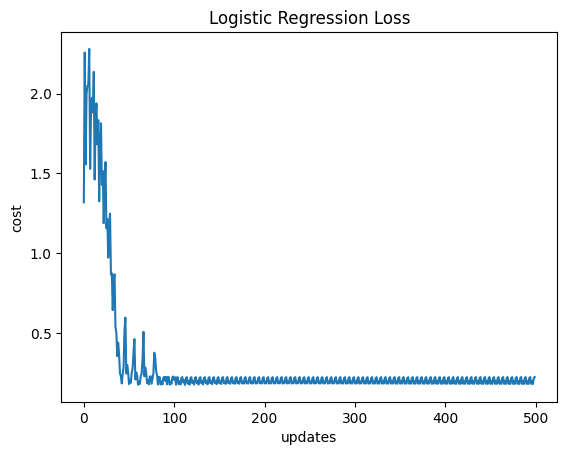

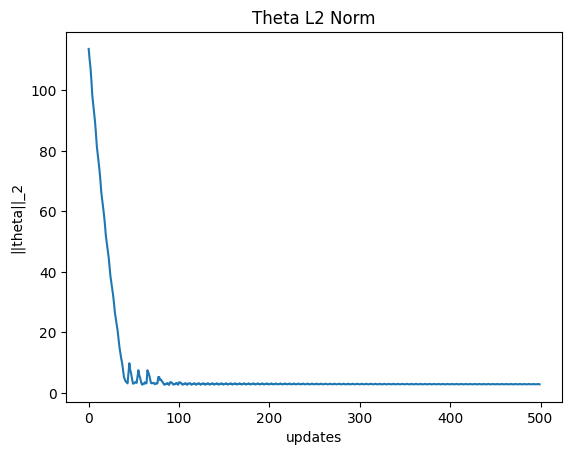

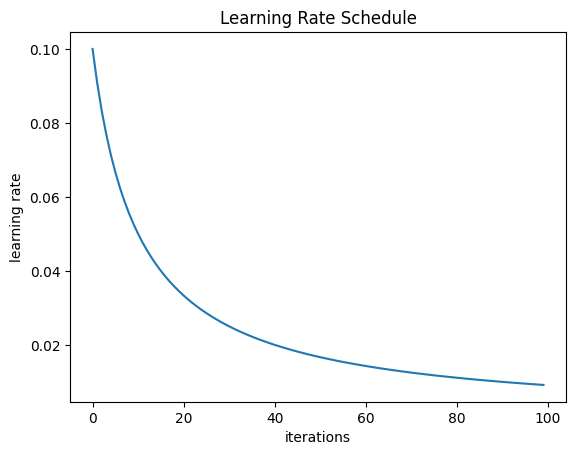

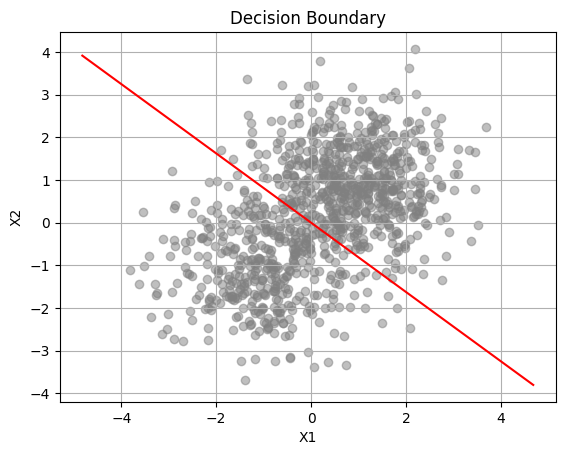

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 2D data with two Gaussian clusters
def generate_data():
    n = 1000
    mu1 = np.array([1, 1])
    mu2 = np.array([-1, -1])
    pik = np.array([0.4, 0.6])  # class probabilities
    X = np.zeros((n, 2))
    y = np.zeros((n, 1))

    for i in range(n):
        u = np.random.rand()
        idx = np.where(u < np.cumsum(pik))[0]
        if len(idx) == 1:
            X[i, :] = np.random.randn(2) + mu1
            y[i] = 1
        else:
            X[i, :] = np.random.randn(2) + mu2
            y[i] = -1
    return X, y


class sgdlr:
    def __init__(self):
        self.num_iter = 100          # number of SGD iterations
        self.lmbda = 1e-9            # regularization strength
        self.tau0 = 10               # learning rate delay
        self.kappa = 1               # learning rate decay exponent
        self.eta = np.zeros(self.num_iter)
        self.batch_size = 200        # mini-batch size
        self.eps = np.finfo(float).eps  # numerical stability

    def fit(self, X, y):
        theta = np.random.randn(X.shape[1], 1)  # random init

        # Learning rate schedule
        for i in range(self.num_iter):
            self.eta[i] = (self.tau0 + i) ** (-self.kappa)

        batch_data, batch_labels = self.make_batches(X, y, self.batch_size)
        num_batches = batch_data.shape[0]
        num_updates = 0

        J_hist = np.zeros((self.num_iter * num_batches, 1))  # cost history
        t_hist = np.zeros((self.num_iter * num_batches, 1))  # theta norm history

        for itr in range(self.num_iter):
            for b in range(num_batches):
                Xb = batch_data[b]
                yb = batch_labels[b]
                J_cost, J_grad = self.lr_objective(theta, Xb, yb, self.lmbda)
                theta = theta - self.eta[itr] * (num_batches * J_grad)
                J_hist[num_updates] = J_cost
                t_hist[num_updates] = np.linalg.norm(theta, 2)
                num_updates += 1
            print(f"iteration {itr}, cost: {J_cost:.6f}")

        # Final classification error
        y_pred = 2 * (self.sigmoid(X.dot(theta)) > 0.5) - 1
        y_err = np.size(np.where(y_pred - y)[0]) / float(y.shape[0])
        print("classification error:", y_err)

        self.generate_plots(X, J_hist, t_hist, theta)
        return theta

    def make_batches(self, X, y, batch_size):
        n = X.shape[0]
        d = X.shape[1]
        num_batches = int(np.ceil(n / batch_size))
        groups = np.tile(range(num_batches), batch_size)[:n]

        batch_data = np.zeros((num_batches, batch_size, d))
        batch_labels = np.zeros((num_batches, batch_size, 1))

        for i in range(num_batches):
            mask = groups == i
            batch_data[i, :np.sum(mask), :] = X[mask, :]
            batch_labels[i, :np.sum(mask), :] = y[mask]
        return batch_data, batch_labels

    def lr_objective(self, theta, X, y, lmbda):
        n = y.shape[0]
        y01 = (y + 1) / 2.0  # map {-1,+1} → {0,1}
        mu = self.sigmoid(X.dot(theta))
        mu = np.clip(mu, self.eps, 1 - self.eps)

        # Logistic regression cost with L2 regularization
        cost = -(1 / n) * np.sum(y01 * np.log(mu) + (1 - y01) * np.log(1 - mu)) \
               + np.sum(lmbda * theta * theta)

        # Gradient of the cost
        grad = X.T.dot(mu - y01) + 2 * lmbda * theta
        return cost, grad

    def sigmoid(self, a):
        return 1 / (1 + np.exp(-a))

    def generate_plots(self, X, J_hist, t_hist, theta):
        # Plot cost history
        plt.figure()
        plt.plot(J_hist)
        plt.title("Logistic Regression Loss")
        plt.xlabel('updates')
        plt.ylabel('cost')
        plt.show()

        # Plot theta norm history
        plt.figure()
        plt.plot(t_hist)
        plt.title("Theta L2 Norm")
        plt.xlabel('updates')
        plt.ylabel('||theta||_2')
        plt.show()

        # Plot learning rate schedule
        plt.figure()
        plt.plot(self.eta)
        plt.title("Learning Rate Schedule")
        plt.xlabel('iterations')
        plt.ylabel('learning rate')
        plt.show()

        # Plot decision boundary
        plt.figure()
        x1 = np.linspace(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 100)
        plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
        plt.plot(x1, -(theta[0] / theta[1]) * x1, color='red')
        plt.title('Decision Boundary')
        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.grid(True)
        plt.show()


if __name__ == "__main__":
    X, y = generate_data()
    sgd = sgdlr()
    theta = sgd.fit(X, y)


# Naive Bayes Classifier


Imagine you receive a letter and want to know if it is from your friend in
**Space Club**, **Car Club**, or **Hockey Club**. You look at the words.
If you see "rocket" and "orbit" a lot — probably Space Club.

Naive Bayes looks at which words appear in a document
and figures out which category it most likely belongs to.

It is **naive** because it makes one big simplifying assumption:

each word appears **independently** of every other word. In reality this is false — the word "ice" makes "hockey" more likely. But even with this
wrong assumption, Naive Bayes works remarkably well in practice, especially
for text classification.

**The entire algorithm reduces to two steps:**
1. **Training:** count how often each word appears in each class
2. **Prediction:** for a new document, find the class whose word frequencies
   best explain what you see

## The Naive Independence Assumption

$$p(x_i \mid y = c,\, \theta) = \prod_{j=1}^{D} p(x_{ij} \mid y = c,\, \theta_{jc})$$



- $x_i$ — the feature vector for document $i$. For text, this is a **bag-of-words**:
  a list of $D$ numbers where $x_{ij} = 1$ if word $j$ appears in document $i$,
  and $x_{ij} = 0$ if it does not.
- $y = c$ — the class label. Could be "space", "cars", "hockey", etc.
- $\theta$ — all the model parameters (all the probabilities we need to learn).
- $\theta_{jc}$ — the probability that word $j$ appears in a document of class $c$.
- $\prod_{j=1}^{D}$ — multiply together $D$ terms, one per word in the dictionary.
  The product replaces a joint probability over all words with a product of
  individual word probabilities — this is the naive assumption.

**Analogy:** Guessing someone's club from their backpack contents. Normally items
are related (a hockey player has both skates AND a stick). Naive Bayes pretends
each item is independent — asks "how likely is a space person to have a telescope?"
and "how likely is a space person to have a star map?" separately, then multiplies.

**Why:** Without it, a joint probability table
over $D$ words would have $2^D$ entries — completely intractable for $D = 1000$.
With independence, we only need $D \times C$ numbers — one per word per class.

## Bernoulli Naive Bayes

$$p(x \mid y=c,\, \theta) = \prod_{i=1}^{n}\prod_{j=1}^{D} p(x_{ij} \mid y=c,\, \theta_{jc}) = \prod_{i=1}^{n}\prod_{j=1}^{D} \text{Bernoulli}(\theta_{jc})$$

Every symbol:

- $\prod_{i=1}^{n}$ — multiply over all $n$ training documents (assumes documents
  are independent of each other)
- $\prod_{j=1}^{D}$ — multiply over all $D$ words in the dictionary
- $\text{Bernoulli}(\theta_{jc})$ — each word $j$ in class $c$ is modeled as a
  biased coin flip:
  - $x_{ij} = 1$ (word present): probability $\theta_{jc}$
  - $x_{ij} = 0$ (word absent): probability $1 - \theta_{jc}$

**The Bernoulli PMF written explicitly:**
$$\text{Ber}(x_{ij} \mid \theta_{jc}) = \theta_{jc}^{x_{ij}}(1-\theta_{jc})^{1-x_{ij}}$$

When $x_{ij}=1$: gives $\theta_{jc}$. When $x_{ij}=0$: gives $1-\theta_{jc}$.
One formula handles both cases cleanly.

**Analogy:** For each word in the dictionary and each club, we have a biased coin.
The "space" coin for "rocket" is very biased toward heads — very likely to appear.
The "space" coin for "goalpost" is nearly always tails — very unlikely to appear.
We flip all coins and multiply the results to get the overall probability.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading 20 newsgroups dataset...
Elapsed time: 1.4248 sec
Number of training docs: 1185
Number of test docs: 1186
Vectorizing input data...
Vocab size: 1000


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Naive Bayes model MLE inference...
Naive Bayes prediction...
Test set accuracy: 0.821247892074199
Generating diagnostic plots...


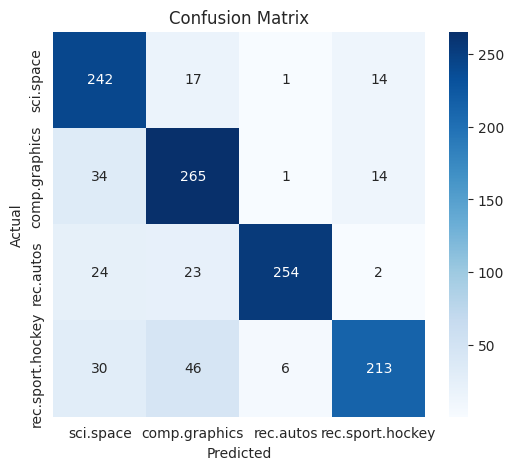

/tmp/ipykernel_12972/3662300917.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=pi, palette="muted")


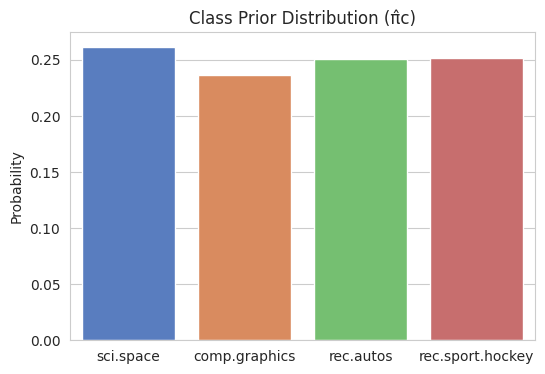

/tmp/ipykernel_12972/3662300917.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probs, y=words, palette="viridis")


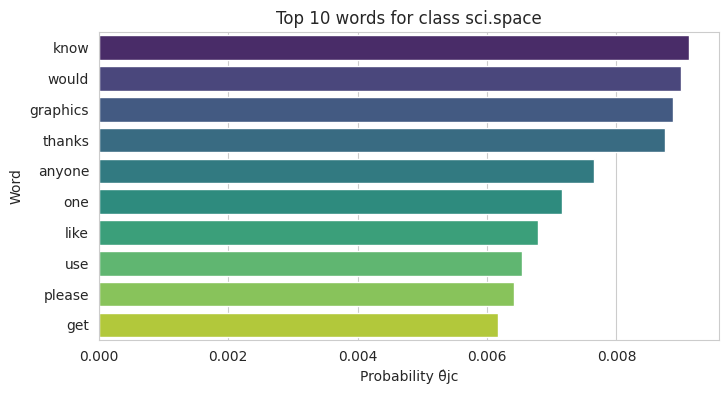

/tmp/ipykernel_12972/3662300917.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probs, y=words, palette="viridis")


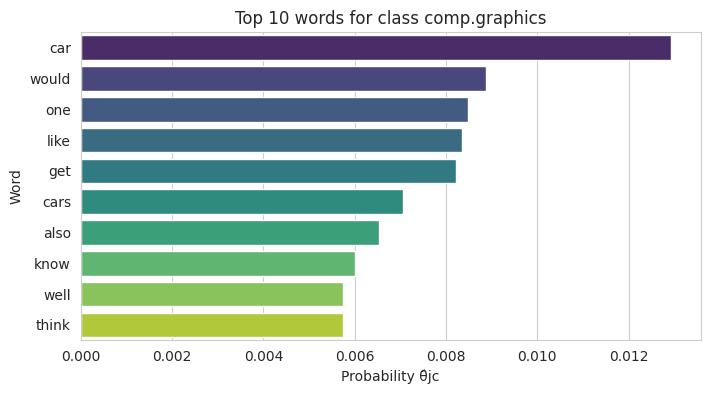

/tmp/ipykernel_12972/3662300917.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probs, y=words, palette="viridis")


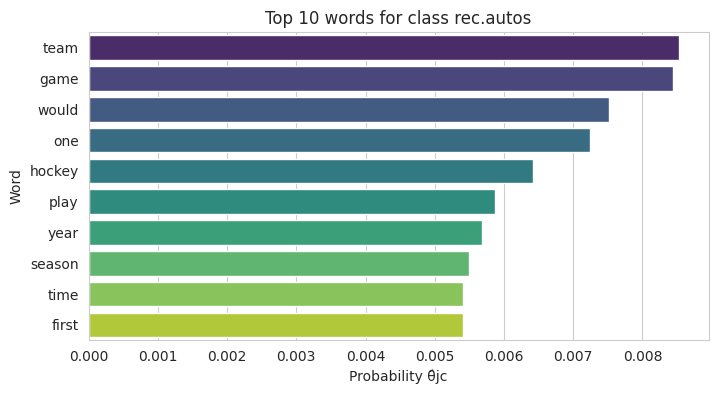

/tmp/ipykernel_12972/3662300917.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probs, y=words, palette="viridis")


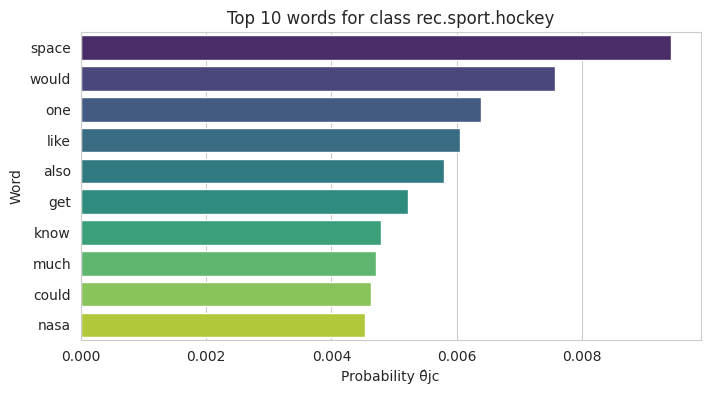

/tmp/ipykernel_12972/3662300917.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=labels, palette="coolwarm")


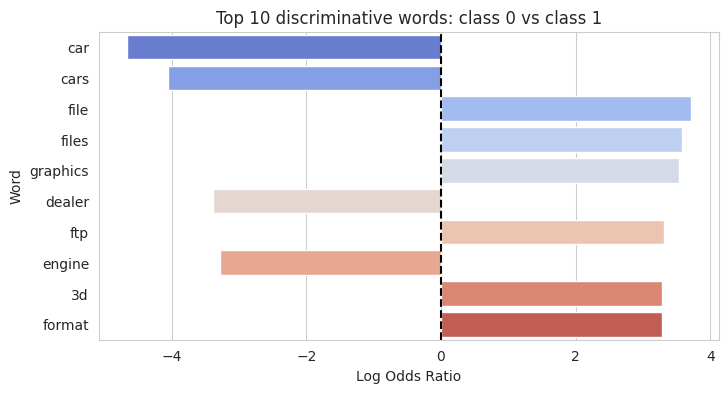

/tmp/ipykernel_12972/3662300917.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=labels, palette="coolwarm")


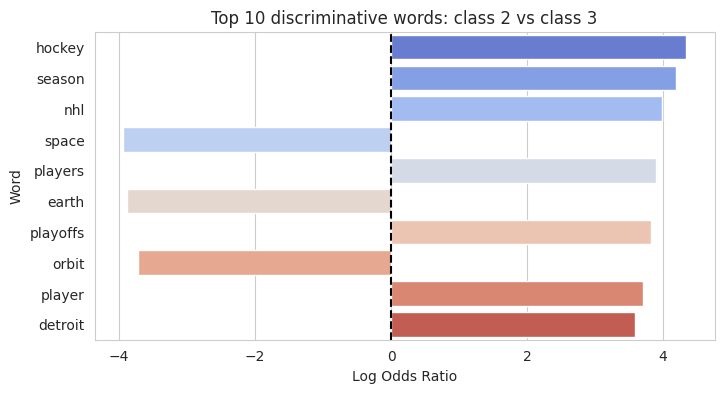

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

tokenizer = RegexpTokenizer(r'\w+')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stop_words.update(['s', 't', 'm', '1', '2'])


class naive_bayes:
    def __init__(self, K, D, idx2word):
        self.K = K
        self.D = D
        self.idx2word = idx2word
        self.pi = np.ones(K)                 # class priors
        self.theta = np.ones((self.D, self.K))  # word probabilities

    def fit(self, X_train, y_train):
        num_docs = X_train.shape[0]
        for doc in range(num_docs):
            label = y_train[doc]
            self.pi[label] += 1
            for word in range(self.D):
                if X_train[doc][word] > 0:
                    self.theta[word][label] += 1
        self.pi = self.pi / np.sum(self.pi)
        self.theta = self.theta / np.sum(self.theta, axis=0)

    def predict(self, X_test):
        num_docs = X_test.shape[0]
        logp = np.zeros((num_docs, self.K))
        for doc in range(num_docs):
            for kk in range(self.K):
                logp[doc][kk] = np.log(self.pi[kk])
                for word in range(self.D):
                    if X_test[doc][word] > 0:
                        logp[doc][kk] += np.log(self.theta[word][kk])
                    else:
                        logp[doc][kk] += np.log(1 - self.theta[word][kk])
        return np.argmax(logp, axis=1)

    def log_odds_ratio(self, c1, c2, top_n=10):
        """Compute log odds ratios between two classes."""
        lor = np.log((self.theta[:, c1] / (1 - self.theta[:, c1])) /
                     (self.theta[:, c2] / (1 - self.theta[:, c2])))
        sorted_idx = np.argsort(-np.abs(lor))[:top_n]
        return [(self.idx2word[i], lor[i]) for i in sorted_idx]

    def plot_log_odds(self, c1, c2, top_n=10):
        """Visualize discriminative words between two classes."""
        lor_words = self.log_odds_ratio(c1, c2, top_n)
        labels, scores = zip(*lor_words)
        plt.figure(figsize=(8, 4))
        sns.barplot(x=scores, y=labels, palette="coolwarm")
        plt.title(f"Top {top_n} discriminative words: class {c1} vs class {c2}")
        plt.xlabel("Log Odds Ratio")
        plt.ylabel("Word")
        plt.axvline(0, color='black', linestyle='--')
        plt.show()



def plot_confusion(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_class_priors(pi, class_names):
    plt.figure(figsize=(6,4))
    sns.barplot(x=class_names, y=pi, palette="muted")
    plt.title("Class Prior Distribution (π̂c)")
    plt.ylabel("Probability")
    plt.show()

def plot_top_words(theta, idx2word, class_names, top_n=10):
    for c in range(len(class_names)):
        sorted_idx = np.argsort(-theta[:, c])[:top_n]
        words = [idx2word[i] for i in sorted_idx]
        probs = theta[sorted_idx, c]
        plt.figure(figsize=(8,4))
        sns.barplot(x=probs, y=words, palette="viridis")
        plt.title(f"Top {top_n} words for class {class_names[c]}")
        plt.xlabel("Probability θ̂jc")
        plt.ylabel("Word")
        plt.show()


if __name__ == "__main__":
    import nltk
    nltk.download('stopwords')

    print("Loading 20 newsgroups dataset...")
    tic = time()
    classes = ['sci.space', 'comp.graphics', 'rec.autos', 'rec.sport.hockey']
    dataset = fetch_20newsgroups(
        shuffle=True,
        random_state=0,
        remove=('headers', 'footers', 'quotes'),
        categories=classes
    )

    X_train, X_test, y_train, y_test = train_test_split(
        dataset.data, dataset.target, test_size=0.5, random_state=0
    )
    toc = time()
    print("Elapsed time: %.4f sec" % (toc - tic))
    print("Number of training docs:", len(X_train))
    print("Number of test docs:", len(X_test))

    print("Vectorizing input data...")
    cnt_vec = CountVectorizer(
        tokenizer=tokenizer.tokenize,
        analyzer='word',
        ngram_range=(1, 1),
        max_df=0.8,
        min_df=2,
        max_features=1000,
        stop_words=list(stop_words) # Convert set to list here
    )
    cnt_vec.fit(X_train)
    vocab = cnt_vec.vocabulary_
    idx2word = {val: key for (key, val) in vocab.items()}
    print("Vocab size:", len(vocab))

    X_train_vec = cnt_vec.transform(X_train).toarray()
    X_test_vec = cnt_vec.transform(X_test).toarray()

    print("Naive Bayes model MLE inference...")
    K = len(set(y_train))
    D = len(vocab)
    nb_clf = naive_bayes(K, D, idx2word)
    nb_clf.fit(X_train_vec, y_train)

    print("Naive Bayes prediction...")
    y_pred = nb_clf.predict(X_test_vec)
    nb_clf_acc = accuracy_score(y_test, y_pred)
    print("Test set accuracy:", nb_clf_acc)

    # Senior-level diagrams
    print("Generating diagnostic plots...")
    plot_confusion(y_test, y_pred, classes)
    plot_class_priors(nb_clf.pi, classes)
    plot_top_words(nb_clf.theta, idx2word, classes, top_n=10)
    nb_clf.plot_log_odds(c1=0, c2=1, top_n=10)
    nb_clf.plot_log_odds(c1=2, c2=3, top_n=10)


# Decision Tree (CART)


The algorithm keeps asking yes/no questions about the data —
"is feature j below threshold t?" — and routes each point
left or right until it lands in a leaf that gives the final prediction.



## Finding the Best Split — Equation 5.42



$$
j^*, t^* = \arg\min_{j \in \{1,\ldots,d\}, \; t \in \tau_j}
\Big( \text{cost}(\{x_i, y_i : x_{ij} \leq t\})
+ \text{cost}(\{x_i, y_i : x_{ij} > t\}) \Big)
$$




Every symbol:

$j*$
  The winning feature dimension — the one measurement that creates the
  cleanest split. The star means "optimal." If your data has 10 columns,
  j* is the index of the column that works best.

t*
  The winning threshold for feature j*. Points with xᵢⱼ ≤ t* go to the
  left child; points with xᵢⱼ > t* go to the right child.

arg min
  "Return the (j, t) pair that achieves the minimum" — not the minimum
  value itself, but the recipe (which feature, which cut) that got there.
  

$j ∈ {1, ..., d}$

We try every feature dimension from 1 to d. No feature is skipped.

$t ∈ τⱼ  τⱼ$ is the set of candidate thresholds for feature j — the midpoints
  between every pair of adjacent sorted values in column j. Trying all
  midpoints guarantees we never miss the best possible cut.

cost(·)
  Impurity of a set. How mixed are the class labels? Zero = perfectly
  pure (all one class). Measured using Gini or entropy.

The search strategy:
  For each of the d features, sort the data in O(n log n).
  Slide through all n−1 midpoint thresholds in O(n) using the
  incremental Gini update (eq. 5.48).
  Total per node: O(d · n log n).

decision tree classifier...
prediction...
test set accuracy:  1.0


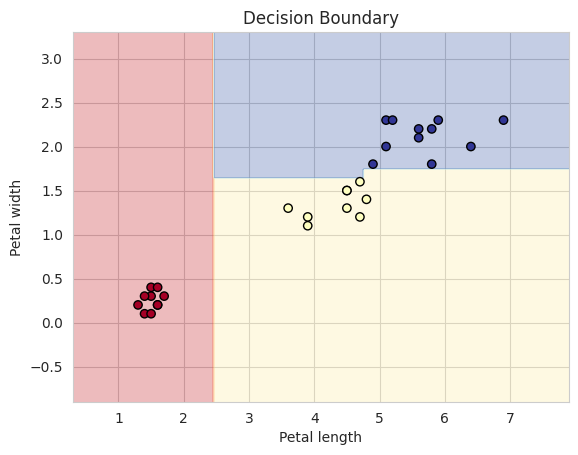

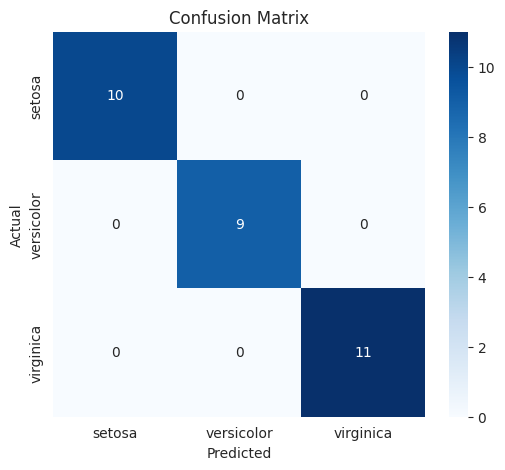

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

class TreeNode():
    def __init__(self, gini, num_samples, num_samples_class, class_label):
        self.gini = gini
        self.num_samples = num_samples
        self.num_samples_class = num_samples_class
        self.class_label = class_label
        self.feature_index = 0
        self.threshold = 0
        self.left = None
        self.right = None

class DecisionTreeClassifier():
    def __init__(self, max_depth=None):
        self.max_depth = max_depth

    def best_split(self, X_train, y_train):
        m = y_train.size
        if m <= 1:
            return None, None
        mk = [np.sum(y_train == k) for k in range(self.num_classes)]
        best_gini = 1.0 - sum((n / m) ** 2 for n in mk)
        best_idx, best_thr = None, None
        for idx in range(self.num_features):
            thresholds, classes = zip(*sorted(zip(X_train[:, idx], y_train)))
            num_left = [0] * self.num_classes
            num_right = mk.copy()
            for i in range(1, m):
                k = classes[i - 1]
                num_left[k] += 1
                num_right[k] -= 1
                gini_left = 1.0 - sum((num_left[x] / i) ** 2 for x in range(self.num_classes))
                gini_right = 1.0 - sum((num_right[x] / (m - i)) ** 2 for x in range(self.num_classes))
                gini = (i * gini_left + (m - i) * gini_right) / m
                if thresholds[i] == thresholds[i - 1]:
                    continue
                if gini < best_gini:
                    best_gini = gini
                    best_idx = idx
                    best_thr = (thresholds[i] + thresholds[i - 1]) / 2
        return best_idx, best_thr

    def gini(self, y_train):
        m = y_train.size
        return 1.0 - sum((np.sum(y_train == k) / m) ** 2 for k in range(self.num_classes))

    def fit(self, X_train, y_train):
        self.num_classes = len(set(y_train))
        self.num_features = X_train.shape[1]
        self.tree = self.grow_tree(X_train, y_train)

    def grow_tree(self, X_train, y_train, depth=0):
        num_samples_class = [np.sum(y_train == k) for k in range(self.num_classes)]
        class_label = np.argmax(num_samples_class)
        node = TreeNode(
            gini=self.gini(y_train),
            num_samples=y_train.size,
            num_samples_class=num_samples_class,
            class_label=class_label,
        )
        if depth < self.max_depth:
            idx, thr = self.best_split(X_train, y_train)
            if idx is not None:
                indices_left = X_train[:, idx] < thr
                X_left, y_left = X_train[indices_left], y_train[indices_left]
                X_right, y_right = X_train[~indices_left], y_train[~indices_left]
                node.feature_index = idx
                node.threshold = thr
                node.left = self.grow_tree(X_left, y_left, depth + 1)
                node.right = self.grow_tree(X_right, y_right, depth + 1)
        return node

    def predict(self, X_test):
        return [self.predict_helper(x_test) for x_test in X_test]

    def predict_helper(self, x_test):
        node = self.tree
        while node.left:
            if x_test[node.feature_index] < node.threshold:
                node = node.left
            else:
                node = node.right
        return node.class_label


# Visualization helpers
def plot_decision_boundary(clf, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array(Z).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.xlabel("Petal length")
    plt.ylabel("Petal width")
    plt.title("Decision Boundary")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


if __name__ == "__main__":
    iris = load_iris()
    X = iris.data[:, [2,3]]
    y = iris.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=42)
    print("decision tree classifier...")
    tree_clf = DecisionTreeClassifier(max_depth=3)
    tree_clf.fit(X_train, y_train)
    print("prediction...")
    y_pred = tree_clf.predict(X_test)
    tree_clf_acc = accuracy_score(y_test, y_pred)
    print("test set accuracy: ", tree_clf_acc)

    # Visual diagnostics
    plot_decision_boundary(tree_clf, X_test, y_test)
    plot_confusion_matrix(y_test, y_pred, iris.target_names)


# Bayesian Linear Regression


Regular linear regression finds ONE set of weights $w$ that best fits the data.
It gives a single prediction: "I predict the house costs $350,000."

Bayesian linear regression says: there are many possible weight vectors that
could explain this data. Instead of picking one, we maintain a **probability
distribution** over all possible weights — and use it to give predictions
with uncertainty estimates: "I predict 350,000 with a standard deviation of 20,000."

## The Setup

We model the output $y$ as a linear function of inputs $x$ plus Gaussian noise:

$$y = w^T x + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

- $x = (x_1, x_2, \ldots, x_d)$ — feature vector of one data point
- $w = (w_1, w_2, \ldots, w_d)$ — weight vector (what we learn)
- $w^T x = w_1x_1 + w_2x_2 + \cdots + w_dx_d$ — linear prediction (dot product)
- $\epsilon$ — noise: random Gaussian error with mean 0 and variance $\sigma^2$
- $\sigma^2$ — noise variance: how much outputs scatter around the prediction

The noise $\epsilon$ accounts for everything our linear model cannot capture —
measurement errors, missing features, inherent randomness.

## The Likelihood Model

$$p(y \mid x,\, \theta) = \mathcal{N}(y \mid w^T x,\, \sigma^2)$$

Since $y = w^T x + \epsilon$ and $\epsilon \sim \mathcal{N}(0, \sigma^2)$, the output $y$
is a Gaussian centered at the prediction $w^T x$:

$$\mathcal{N}(y \mid w^Tx, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(y - w^Tx)^2}{2\sigma^2}\right)$$

Every symbol:
- $w^Tx$ — the **mean** of the prediction: our best single guess for $y$
- $\sigma^2$ — the **variance**: how spread out the prediction uncertainty is
- $(y - w^Tx)^2$ — squared distance from prediction to actual value
- $\frac{1}{\sqrt{2\pi\sigma^2}}$ — normalization constant (makes it integrate to 1)

**Interpretation:** For a given input $x$ and weights $w$, the output $y$ is most
likely to be near $w^Tx$, with probability decaying as you move away.
Larger $\sigma^2$ = wider bell curve = more uncertain predictions.

**Analogy:** You predict a plant will grow 30cm. But due to random
variation (rain, soil, sunlight), the actual height will be close to 30cm but
not exact. The Gaussian describes this uncertainty — values near 30cm are
likely, values far from 30cm are increasingly unlikely.

## The Negative Log Likelihood — Full Derivation

Starting from the likelihood over all $N$ training examples:

$$p(y|X,\theta) = \prod_{n=1}^{N}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(y_n - w^Tx_n)^2}{2\sigma^2}\right)$$

Taking the negative log (turning products into sums):

$$\text{NLL}(w, \sigma^2) = -\log\prod_{n=1}^N p(y_n|x_n,\theta) = -\sum_{n=1}^N \log p(y_n|x_n,\theta)$$

Expanding $\log\mathcal{N}$:

$$= -\sum_{n=1}^N\left[-\frac{1}{2}\log(2\pi\sigma^2) - \frac{(y_n-w^Tx_n)^2}{2\sigma^2}\right]$$

$$= \boxed{\frac{1}{2\sigma^2}\sum_{n=1}^{N}(y_n - w^Tx_n)^2 + \frac{N}{2}\log(2\pi\sigma^2)}$$

Every term explained:
- $(y_n - w^Tx_n)$ — **residual**: how far the prediction is from the truth for example $n$
- $(y_n - w^Tx_n)^2$ — **squared residual**: always positive, large errors penalized more
- $\sum_{n=1}^N(\cdots)^2$ — **sum of squared errors (SSE)**: total prediction error
- $\frac{1}{2\sigma^2}$ — scale factor: larger noise $\sigma^2$ means individual errors matter less
- $\frac{N}{2}\log(2\pi\sigma^2)$ — constant w.r.t. $w$ (only matters when optimizing $\sigma^2$)


Minimizing NLL w.r.t. $w$ (with $\sigma^2$ fixed) is exactly
the same as minimizing the sum of squared errors — ordinary least squares (OLS).
The probabilistic formulation recovers the classical method as a special case.

## The Gaussian Prior — Bayesian Regularization

$$p(w) = \prod_d \mathcal{N}(w_d \mid 0,\, \tau^2)$$

A **prior distribution** encodes our belief about what the weights should look like
BEFORE seeing any data.

Every symbol:
- $\prod_d$ — each weight dimension is assumed independent (factorized prior)
- $\mathcal{N}(w_d|0, \tau^2)$ — each weight $w_d$ is a priori Gaussian with:
  - **Mean 0** — weights should be near zero before seeing data (no direction preferred)
  - **Variance $\tau^2$** — how spread out our prior belief is

**Effect of $\tau^2$:**
- Small $\tau^2$: strong belief weights are near zero — heavy regularization
- Large $\tau^2$: vague prior, weights can be anything — weak regularization
- $\tau^2 \to \infty$: flat (uninformative) prior — no regularization, reduces to OLS

**The Bayesian connection to Ridge regression:**

Taking $-\log p(w)$:
$$-\log p(w) = \sum_d\frac{w_d^2}{2\tau^2} + \text{const} = \frac{\|w\|^2}{2\tau^2} + \text{const}$$

This is exactly the L2 regularization term with $\lambda = \sigma^2/\tau^2$.

**MAP estimation** (Maximum A Posteriori) maximizes the posterior $p(w|y,X)$:
$$\log p(w|y,X) = \underbrace{-\text{NLL}(w,\sigma^2)}_{\text{log likelihood}} + \underbrace{-\frac{\|w\|^2}{2\tau^2}}_{\text{log prior}} + \text{const}$$

Maximizing log posterior = minimizing $\text{NLL} + \lambda\|w\|^2$.
**Ridge regression IS Bayesian linear regression with a Gaussian prior.**

**Analogy:** Before looking at any data, you believe all weights
should be near zero — no feature should be too important. This belief is the
prior. The data can override this belief, but only if the evidence is strong enough.
Weak evidence → weights stay near zero. Strong evidence → weights move away from zero.

## The Regularized Objective and Ridge Solution (Equations 6.8 and 6.9)

### The Regularized Objective (Equation 6.8)

$$\min_w\,\text{NLL}(w, \sigma^2) + \lambda\|w\|_2^2$$

- $\text{NLL}(w,\sigma^2)$ — data fit term: how well $w$ explains the training data
- $\lambda\|w\|_2^2 = \lambda(w_1^2 + w_2^2 + \cdots + w_d^2)$ — regularization: penalizes large weights
- $\lambda$ — regularization strength: the balance between fitting data and keeping weights small

**The two forces in tension:**
- NLL says: "adjust weights as much as needed to fit the training data"
- $\lambda\|w\|^2$ says: "keep all weights as small as possible"

### The Ridge Regression Solution

$$\hat{w}_{\text{ridge}} = (X^TX + \lambda I)^{-1}X^Ty$$

**What $\lambda I$ does to the matrix:**
- $X^TX$ may have very small eigenvalues — near-singular, unstable to invert
- Adding $\lambda$ to every diagonal entry lifts all eigenvalues by $\lambda$
- The matrix $(X^TX + \lambda I)$ is always well-conditioned and invertible when $\lambda > 0$

**Effect on the weights:**

| $\lambda$ | Behavior |
|---|---|
| $\lambda = 0$ | OLS — weights unconstrained, may overfit |
| Small $\lambda$ | Slight shrinkage toward zero |
| Large $\lambda$ | Strong shrinkage — all weights near zero (underfitting) |
| $\lambda \to \infty$ | $\hat{w} \to 0$ — completely ignores data |

**The bias-variance trade-off:**
- $\lambda = 0$: low bias, high variance — fits training data well, poor generalization
- Large $\lambda$: high bias, low variance — underfits training data, more stable on new data
- Optimal $\lambda$: chosen by cross-validation on a held-out validation set

**Analogy:** The $\lambda I$ term is like rubber bands connecting every
weight to zero. Without rubber bands, weights stretch as far as needed to fit
training data perfectly. With rubber bands, weights are pulled toward zero —
they only stretch far if the data very strongly supports it.
The right amount of rubber band tension gives the best predictions on new data.

 0 iter, mse: 0.4215
 1 iter, mse: 0.4098
 2 iter, mse: 0.4023
 3 iter, mse: 0.3976
 4 iter, mse: 0.3947
 5 iter, mse: 0.3928
 6 iter, mse: 0.3917
 7 iter, mse: 0.3910
 8 iter, mse: 0.3906
 9 iter, mse: 0.3903
 10 iter, mse: 0.3902
 11 iter, mse: 0.3901
 12 iter, mse: 0.3900
 13 iter, mse: 0.3900
 14 iter, mse: 0.3900
 15 iter, mse: 0.3900
 16 iter, mse: 0.3900
 17 iter, mse: 0.3900
 18 iter, mse: 0.3900
 19 iter, mse: 0.3901
[-0.09307321  0.52858812]


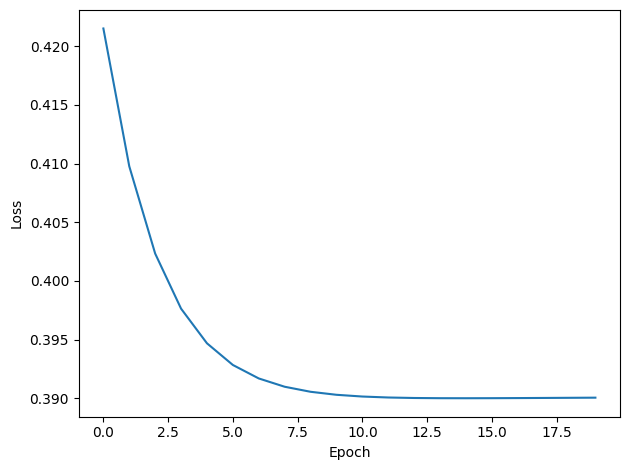

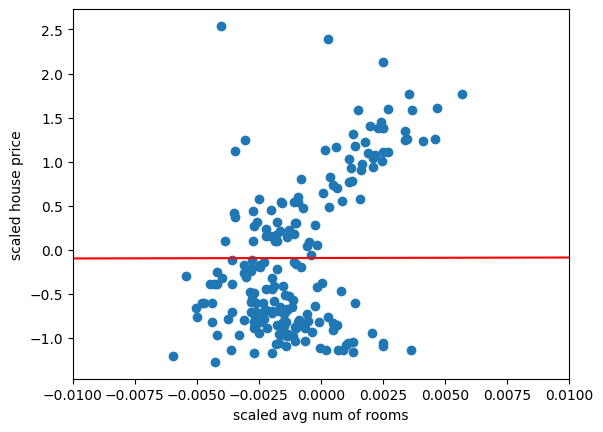

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

class ridge_reg():
  def __init__(self, n_iter = 20, learning_rate = 1e-3, lmbda = 0.1):
    self.n_iter = n_iter
    self.learning_rate = learning_rate
    self.lmbda = lmbda

  def fit(self, X, y):
    X = np.insert(X, 0, 1, axis = 1)
    self.loss = []
    self.w = np.random.rand(X.shape[1])   # Initialize weights randomly

    for i in range(self.n_iter):
      y_pred = X.dot(self.w)
      mse = np.mean(0.5*(y - y_pred)**2 + 0.5*self.lmbda*self.w.T.dot(self.w))
      self.loss.append(mse)
      print(" %d iter, mse: %.4f" %(i, mse))

      grad_w = - (y - y_pred).dot(X) + self.lmbda*self.w   # Computes gradient wrt w
      self.w -= self.learning_rate * grad_w                # Updates the weights


  def predict(self, X):
      X = np.insert(X, 0, 1, axis=1)   # Inserts const 1 for the bias term
      y_pred = X.dot(self.w)
      return y_pred


if __name__ == "__main__":
    # Load dataset
    X, y = fetch_california_housing(return_X_y=True)

    X_reg = X[:,2].reshape(-1,1)   # Average number of rooms
    X_std = (X_reg - X_reg.mean())/X.std()   # Standard scaling
    y_std = (y - y.mean())/y.std()           # Standard scaling

    # Use a subset for faster training
    X_std = X_std[:200,:]
    y_std = y_std[:200]

    rr = ridge_reg()
    rr.fit(X_std, y_std)
    y_pred = rr.predict(X_std)

    print(rr.w)

    # Plot training loss curve
    plt.figure()
    plt.plot(rr.loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.tight_layout()
    plt.show()

    # Plot regression line vs. scatter data
    plt.figure()
    plt.scatter(X_std, y_std)
    plt.plot(np.linspace(-1,1), rr.w[1]*np.linspace(-1,1)+rr.w[0], c='red')
    plt.xlim([-0.01,0.01])
    plt.xlabel("scaled avg num of rooms")
    plt.ylabel("scaled house price")
    plt.show()

Output()

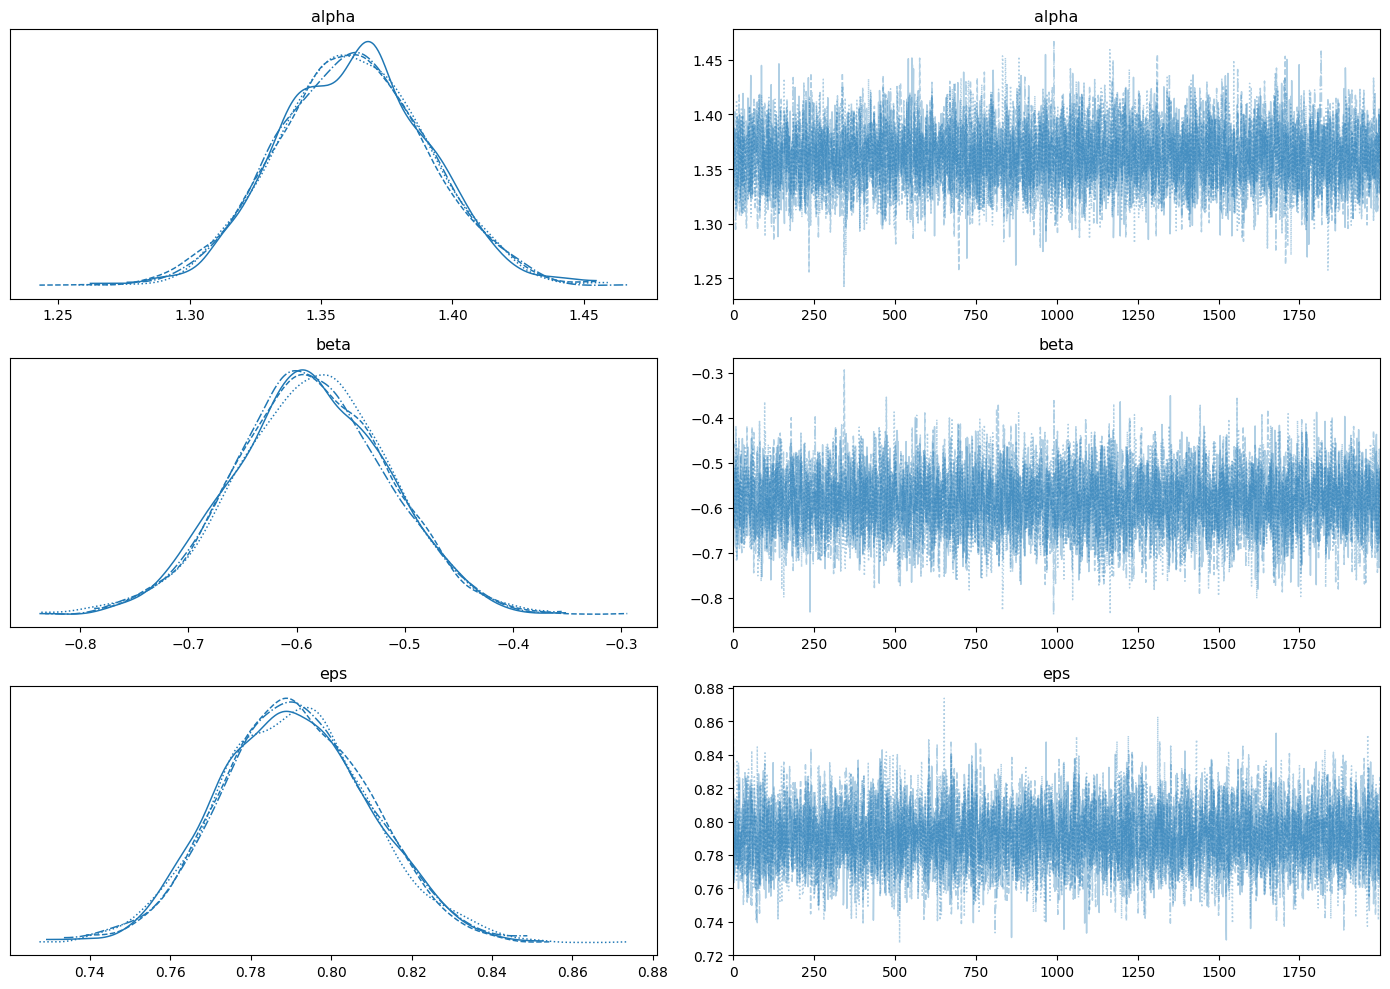

Output()

ERROR:pymc.stats.convergence:There were 21 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


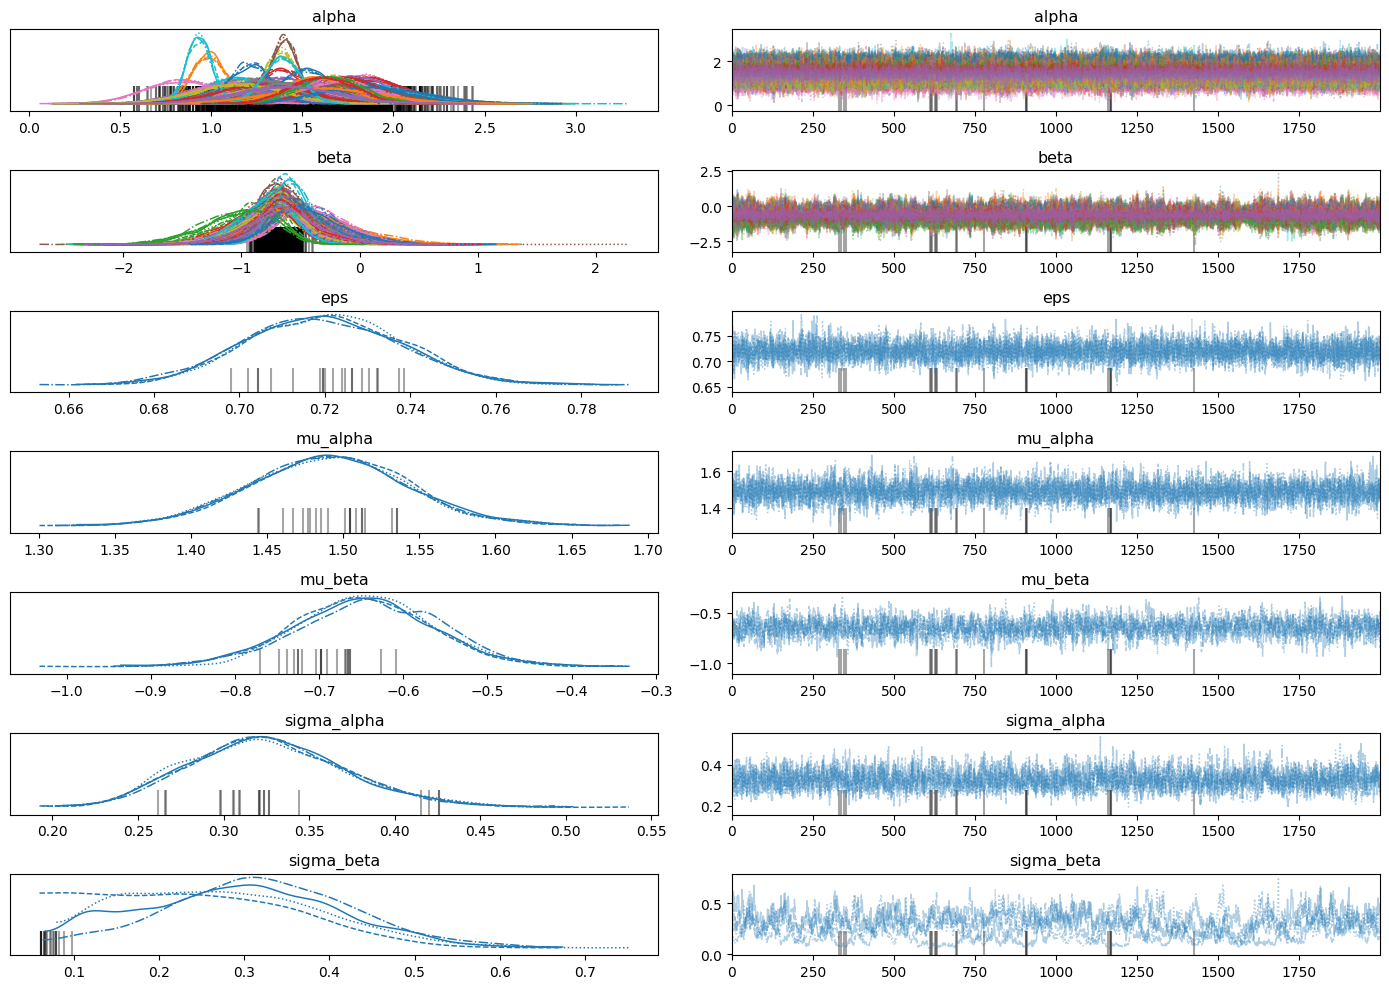

Output()

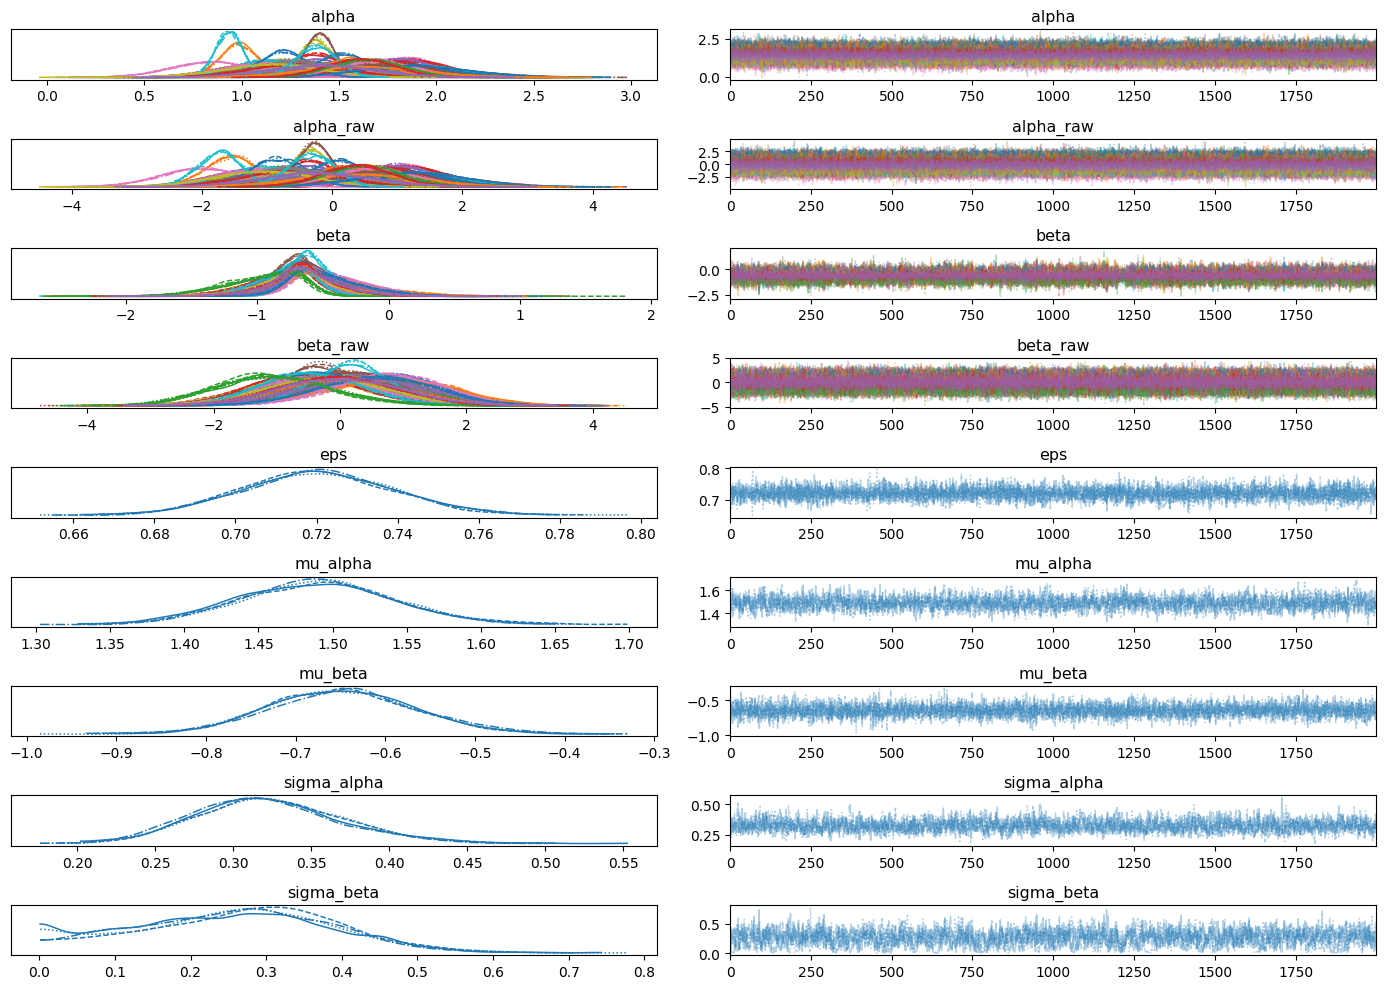

Output()

ERROR:pymc.stats.convergence:There were 35 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


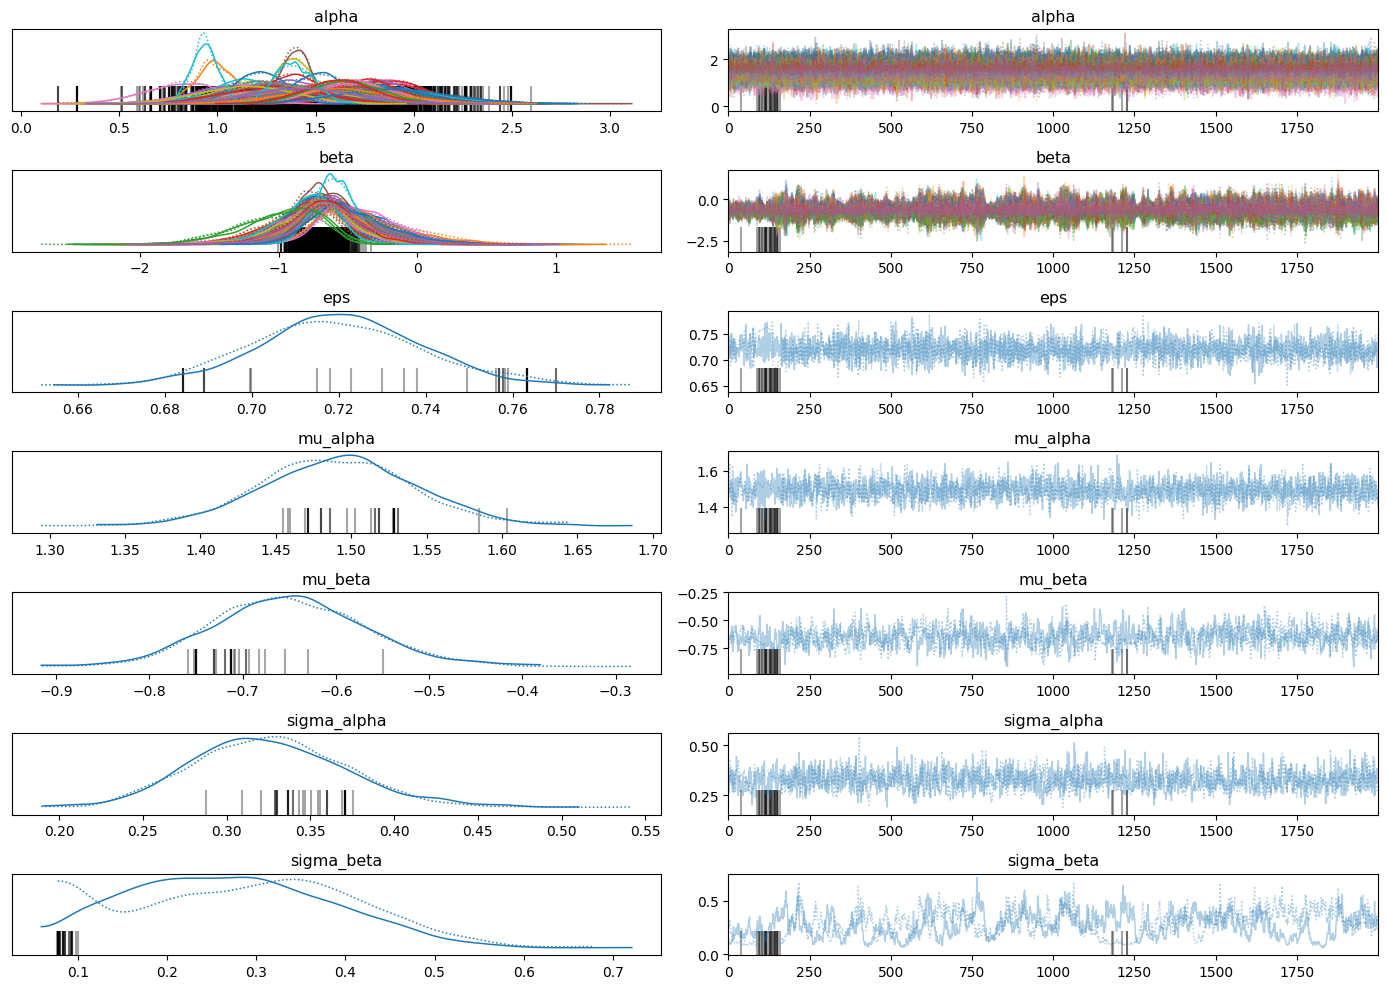

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

def main():
    # Load data
    data = pd.read_csv("/radon.txt")
    county_names = data["county"].unique()
    county_idx = data["county_code"].values
    floor = data["floor"].values
    log_radon = data["log_radon"].values

    # 1. Complete pooling
    with pm.Model() as pooled_model:
        alpha = pm.Normal("alpha", mu=0, sigma=10)
        beta = pm.Normal("beta", mu=0, sigma=10)
        eps = pm.HalfNormal("eps", sigma=1)
        mu = alpha + beta * floor
        y_like = pm.Normal("y_like", mu=mu, sigma=eps, observed=log_radon)
        pooled_trace = pm.sample(2000, tune=2000, target_accept=0.9,
                                 chains=4, random_seed=42)

    az.plot_trace(pooled_trace, figsize=(14, 10))
    plt.tight_layout()
    plt.show()

    # 2. Hierarchical centered
    with pm.Model() as hier_centered:
        mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=10)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=10)
        mu_beta = pm.Normal("mu_beta", mu=0, sigma=10)
        sigma_beta = pm.HalfNormal("sigma_beta", sigma=10)
        alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha,
                          shape=len(county_names))
        beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta,
                         shape=len(county_names))
        eps = pm.HalfNormal("eps", sigma=1)
        mu = alpha[county_idx] + beta[county_idx] * floor
        y_like = pm.Normal("y_like", mu=mu, sigma=eps, observed=log_radon)
        hier_centered_trace = pm.sample(2000, tune=2000, target_accept=0.9,
                                        chains=4, random_seed=42)

    az.plot_trace(hier_centered_trace, figsize=(14, 10))
    plt.tight_layout()
    plt.show()

    # 3. Hierarchical non-centered
    with pm.Model() as hier_noncentered:
        mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=10)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=10)
        mu_beta = pm.Normal("mu_beta", mu=0, sigma=10)
        sigma_beta = pm.HalfNormal("sigma_beta", sigma=10)
        alpha_raw = pm.Normal("alpha_raw", mu=0, sigma=1,
                              shape=len(county_names))
        beta_raw = pm.Normal("beta_raw", mu=0, sigma=1,
                             shape=len(county_names))
        alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_raw)
        beta = pm.Deterministic("beta", mu_beta + sigma_beta * beta_raw)
        eps = pm.HalfNormal("eps", sigma=1)
        mu = alpha[county_idx] + beta[county_idx] * floor
        y_like = pm.Normal("y_like", mu=mu, sigma=eps, observed=log_radon)
        hier_noncentered_trace = pm.sample(2000, tune=2000, target_accept=0.9,
                                           chains=4, random_seed=42)

    az.plot_trace(hier_noncentered_trace, figsize=(14, 10))
    plt.tight_layout()
    plt.show()

    # 4. Alternative hierarchical model
    with pm.Model() as hierarchical_model:
        mu_a = pm.Normal("mu_alpha", mu=0., sigma=100)
        sigma_a = pm.HalfNormal("sigma_alpha", sigma=100)
        mu_b = pm.Normal("mu_beta", mu=0., sigma=100)
        sigma_b = pm.HalfNormal("sigma_beta", sigma=100)
        a = pm.Normal("alpha", mu=mu_a, sigma=sigma_a,
                      shape=len(county_names))
        b = pm.Normal("beta", mu=mu_b, sigma=sigma_b,
                      shape=len(county_names))
        eps = pm.HalfNormal("eps", sigma=100)
        radon_est = a[county_idx] + b[county_idx] * floor
        y_like = pm.Normal("y_like", mu=radon_est, sigma=eps,
                           observed=log_radon)
        trace = pm.sample(2000, tune=2000, target_accept=0.9)

    az.plot_trace(trace, figsize=(14, 10))
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


# Gaussian Process Regression

## The Core Idea

Regular linear regression (or even Bayesian linear regression) tries to find **one fixed function** (a straight line or plane) that explains the data.

**Gaussian Process Regression (GPR)** is much more powerful and flexible. It puts a **probability distribution over all possible functions**.

Instead of learning fixed weights, a GP learns a **distribution over functions**. After seeing data, it updates its beliefs and gives:
- A smooth **mean prediction** curve
- **Uncertainty bands** that grow as we move away from observed data

**Simple Analogy**: Imagine you are trying to guess the shape of a hidden wavy curve. A GP starts with thousands of possible wiggly curves in its mind (the prior). When it sees real data points, it throws away unrealistic curves and keeps only the ones that fit the data well. The result is a smart average curve with confidence bands.

GPs are non-parametric — they can model very complex, smooth, non-linear relationships without choosing the number of parameters in advance.

---

## Basic Regression Model

We start with a simple supervised regression problem:

$$
f(x) = x^T w \qquad y = f(x) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma_n^2)
$$

**Every symbol explained**:
- $x \in \mathbb{R}^d$ — input features (e.g., time, temperature, location)
- $w$ — weight vector (in classical regression)
- $f(x)$ — the **true underlying function** we want to discover
- $y$ — observed noisy measurement
- $\epsilon$ — Gaussian noise (measurement error, missing variables, randomness)
- $\sigma_n^2$ — noise variance (how noisy our observations are)

**Simple Analogy**: You have a perfect invisible curve $f(x)$. But when you measure it with a shaky ruler, you get noisy points $y$. The noise $\epsilon$ explains why points don't lie perfectly on the curve.

---

## The Likelihood Function

Assuming independent Gaussian noise, the likelihood of the data is:

$$
p(y \mid X, w) = \prod_{i=1}^n \mathcal{N}(y_i \mid x_i^T w, \sigma_n^2) \quad \sim \quad \mathcal{N}(Xw, \sigma_n^2 I)
$$

**Symbols**:
- $X$ — $n \times d$ design matrix (all training inputs)
- $y$ — vector of $n$ observed targets
- $I$ — identity matrix

**Simple Analogy**:  
This equation says: “Given weights $w$, each observation should be close to the prediction $x_i^T w$, with Gaussian scatter controlled by $\sigma_n^2$.”  
It's the probability of seeing our noisy data if the model is correct.

---

## Bayesian Posterior over Weights

In the Bayesian framework, we put a prior on the weights $w \sim \mathcal{N}(0, \Sigma_p)$ and combine it with the likelihood:

$$
p(w \mid X, y) \propto \exp\left( -\frac{1}{2\sigma_n^2} \| y - Xw \|^2 \right) \exp\left( -\frac{1}{2} w^T \Sigma_p^{-1} w \right)
$$

After completing the square, we get a Gaussian posterior:

$$
p(w \mid X, y) \sim \mathcal{N} \left( \bar{w}, \left( \frac{1}{\sigma_n^2} X^T X + \Sigma_p^{-1} \right)^{-1} \right)
$$

**Simple Analogy**:  
You have two sources of information:
1. **Data evidence** (first exponential term) — "What do my measurements say?"
2. **Prior belief** (second term) — "Before seeing data, I believe weights should be reasonable."

Bayes’ rule combines them to get the **posterior** — your updated belief about $w$.

---

## The Key Matrix A

$$
A = \sigma_n^{-2} X^T X + \Sigma_p^{-1}
$$

**Simple meaning**:  
This matrix $A$ combines information from the data ($X^T X$) and our prior beliefs ($\Sigma_p^{-1}$). Inverting $A$ gives us the posterior covariance (uncertainty) over the weights.

---

## Joint Distribution for Training + Test Points

This is where Gaussian Processes become truly elegant. Instead of working with weights $w$, we work directly in **function space**.

We consider both training points $f$ and test points $f_*$ together:

$$
\begin{pmatrix}
f \\
f_*
\end{pmatrix}
\sim \mathcal{N} \left(
\begin{pmatrix}
\mu \\
\mu_*
\end{pmatrix},
\begin{pmatrix}
K & K_* \\
K_*^T & K_{**}
\end{pmatrix}
\right)
$$

**Symbols explained**:
- $K = \kappa(X, X)$ — covariance (kernel) matrix between training points
- $K_* = \kappa(X, X_*)$ — covariance between training and test points
- $K_{**} = \kappa(X_*, X_*)$ — covariance among test points
- $\kappa(\cdot, \cdot)$ — kernel function (measures similarity between inputs)

**Simple Analogy**:  
Think of every point (old and new) as people at a party. The kernel tells you **how similar** any two people are. Close friends (similar inputs) have high covariance — they tend to behave similarly. Distant strangers have low covariance.

---

## Posterior Predictive Distribution  — The Most Important Equation

Using the rules of conditional Gaussians, we get the **posterior predictive distribution** at new test points $X_*$:

$$
p(f_* \mid X_*, X, f) \sim \mathcal{N}(\mu_*, \Sigma_*)
$$

Where:

$$
\mu_* = \mu(X_*) + K_*^T K^{-1} (f - \mu(X))
$$

$$
\Sigma_* = K_{**} - K_*^T K^{-1} K_*
$$

**Deep Interpretation**:
- $\mu_*$ → **Mean prediction** at new points (best guess)
- $\Sigma_*$ → **Uncertainty** at new points

**Simple Analogy**:  
The term $K_*^T K^{-1} (f - \mu(X))$ is like **smart interpolation**. It looks at how similar the new point is to all observed points, then smoothly adjusts the prediction based on nearby data.  
The uncertainty $\Sigma_*$ grows naturally as you move far from training data — the model becomes less confident.

This is the **kernel trick** in action: we never explicitly compute infinite-dimensional features. The kernel computes similarities directly.

---

## Why Gaussian Processes Are Powerful

- **Non-parametric**: No need to choose number of parameters
- **Built-in uncertainty**: Predictions come with confidence intervals
- **Flexible**: Choice of kernel controls smoothness, periodicity, etc.
- **Exact inference** possible for small/medium datasets (though cubic cost $O(n^3)$)

**Limitation**: Computationally expensive for large $n$ (due to matrix inversion). Modern approximations (Sparse GPs, variational GPs) address this.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

np.random.seed(42)

class KNN:
    def __init__(self, K):
        self.K = K

    def euclidean_distance(self, x1, x2):
        dist = 0
        for i in range(len(x1)):
            dist += np.power((x1[i] - x2[i]), 2)
        return np.sqrt(dist)

    def knn_search(self, X_train, y_train, Q):
        y_pred = np.empty(Q.shape[0])
        for i, query in enumerate(Q):
            idx = np.argsort([self.euclidean_distance(query, x) for x in X_train])[:self.K]
            knn_labels = y_train[idx]
            y_pred[i] = np.mean(knn_labels)
        return y_pred


if __name__ == "__main__":
    # Iris dataset
    iris = datasets.load_iris()
    X = iris.data[:, :2]   # first two features
    y = iris.target

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    K = 4
    knn = KNN(K)
    y_pred = knn.knn_search(X_train, y_train, X_test)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], s=100, marker="x", color="r", label="train data")
    plt.scatter(X_test[:, 0], X_test[:, 1], s=100, marker="o", color="b", label="query points")
    plt.title(f"K Nearest Neighbors (K={K})")
    plt.legend()
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True)
    plt.show()


# Markov Models & PageRank

## Markov Models

A Markov model assumes the **future depends only on the present**, not the full history.

$$p(x_1, \dots, x_T) = p(x_1) \prod_{t=2}^T p(x_t | x_{t-1})$$

### Transition Matrix
$$
A_{ij} = p(\text{go to } j | \text{currently in } i)
$$

**Two-state example**:
$$
A = \begin{pmatrix} 1-\alpha & \alpha \\ \beta & 1-\beta \end{pmatrix}
$$

## Stationary Distribution

After many steps, the system reaches equilibrium:

$$
\pi = \pi A \quad \text{}
$$

$\pi$ = long-term probability of being in each state.

## PageRank Algorithm

**Core Idea**: Importance of a page = sum of importance of pages linking to it.

**Damped Transition Matrix** :
- With probability $p$: follow a link
- With probability $1-p$: jump randomly (teleport)

**Power Method**:
Repeatedly do:
$$v \leftarrow A v / \|v\|_1$$

Until convergence → gives PageRank scores.

**Why it works**: PageRank vector $\pi$ is the principal eigenvector of the transition matrix $A$.

## Summary

- Markov chains model sequences with limited memory.
- PageRank is a brilliant application of Markov chains on the web graph.
- The damping factor makes the algorithm robust and guarantees convergence.

In [1]:
import numpy as np
from numpy.linalg import norm

np.random.seed(42)

class PageRank:
    def __init__(self, max_iter=100, tolerance=1e-6, damping=0.85):
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.damping = damping

    def build_transition_matrix(self, G):
        """
        Build the transition matrix A from adjacency matrix G.
        G[i,j] = 1 if page j links to page i, else 0.
        """
        n = G.shape[0]
        A = np.zeros((n, n))
        for j in range(n):
            d_j = np.sum(G[:, j])  # out-degree of page j
            if d_j != 0:
                A[:, j] = self.damping * (G[:, j] / d_j) + (1 - self.damping) / n
            else:
                # If no outgoing links, jump uniformly
                A[:, j] = 1.0 / n
        return A

    def power_iteration(self, A):
        """
        Compute dominant eigenvector (PageRank vector) using power iteration.
        """
        n = A.shape[0]
        v = np.random.rand(n)
        v = v / norm(v)
        for _ in range(self.max_iter):
            old_v = v
            v = np.dot(A, v)
            v = v / norm(v)
            if norm(v - old_v) < self.tolerance:
                break
        return v

if __name__ == "__main__":
    # Example: 4-page web graph
    # G[i,j] = 1 if page j links to page i
    G = np.array([
        [0, 1, 1, 0],  # Page 0 receives links from 1 and 2
        [1, 0, 0, 0],  # Page 1 receives link from 0
        [0, 1, 0, 1],  # Page 2 receives links from 1 and 3
        [0, 0, 1, 0]   # Page 3 receives link from 2
    ])

    pr = PageRank()
    A = pr.build_transition_matrix(G)
    pagerank_vector = pr.power_iteration(A)

    print("Transition matrix A:\n", A)
    print("\nPageRank vector (stationary distribution):\n", pagerank_vector)
    print("\nSum of ranks (should be 1 after normalization):", np.sum(pagerank_vector))


Transition matrix A:
 [[0.0375 0.4625 0.4625 0.0375]
 [0.8875 0.0375 0.0375 0.0375]
 [0.0375 0.4625 0.0375 0.8875]
 [0.0375 0.0375 0.4625 0.0375]]

PageRank vector (stationary distribution):
 [0.54167401 0.53385535 0.56788905 0.31478526]

Sum of ranks (should be 1 after normalization): 1.9582036675989067
